#  TWISSTNTERN Plots

This Notebook contains:
- *A configuration Pannel! to ease tweaks*
- **2D Residual Analysis**: Compare two datasets using heatmaps and statistical metrics.
- **3D Visualization**: Explore data through an interactive 3D histogram.
- **Model Comparison -- Figure 5**: Compare the outputs of different models against a "ground truth" reference. --
requires python file metrics.py. right now we download it- think about putting it all in a cell
- **Data Plotting**: Visualizes the Littorina dataset.

---


In [6]:
# IMPORTS AND SETUP
# ============================================================================

# installing torch for the metrics calculation
# pip install torch --index-url https://download.pytorch.org/whl/cpu

# importing torch
#import torch

# importing twisstntern
# ============================================================================
try:
    from twisstntern.utils import (
        dump_data, cartizian, T1_lim, T2_lim, T3_lim, 
        T1, T2, T3, h, return_triangle_coord, number_triangles
    )
    from twisstntern.visualization import (
    get_professional_colormap,
    plot_ternary_heatmap_data,
    plot_density_colored_radcount,
    plot_fundamental_asymmetry,
    plot_results,
    plot,
    draw_grey_grid_lines
    )
    from twisstntern.analysis import triangles_analysis, fundamental_asymmetry
    print("✓ TWISSTNTERN library loaded successfully!")
except ImportError as e:
    print(f"✗ Error importing TWISSTNTERN: {e}")   
    print("Make sure twisstntern is installed and you're in the correct directory")
    sys.exit(1)

# System / OS / Utilities
import sys
import os
import time
import math
import re
import warnings
from pathlib import Path

import contextlib
import io
import urllib.request

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import SymLogNorm, Normalize, ListedColormap, LinearSegmentedColormap
from matplotlib.patches import Polygon
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Scientific Computing / Statistics
from scipy import stats
from scipy.stats import chi2, gaussian_kde
from sklearn.neighbors import NearestNeighbors


# Optimal transport (for Wasserstein distances)
try:
    import ot
    HAS_OT = True
    print("✓ Optimal transport library loaded")
except ImportError:
    print("⚠️ Installing optimal transport library...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "POT"])
    import ot
    HAS_OT = True
    print("✓ Optimal transport library installed and loaded")




# Import metrics if available
try:
    from metrics import compute_all_metrics, load_data
    print("✓ Custom metrics module loaded")
except ImportError:
    print("⚠️ Custom metrics module not found (metrics.py)")
    compute_metrics = None

# Setup plotting
plt.style.use('default')  # Start with clean style
sns.set_palette("bright")

# Configure matplotlib for better interactivity
#%matplotlib qt5
# matplotlib.use('nbagg')
# %matplotlib nbagg

#%matplotlib widget
%matplotlib inline
print("✓ Interactive matplotlib backend configured")

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


print("Right now- cannot make 3D plots interactive, though they should")
print("IMPORTING THE FILES")


# downloading the metrics.py-- if not already available
url = "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/metrics.py"
filename = "metrics.py"

# Download only if not already present
if not os.path.exists(filename):
    print(f"⬇️ Downloading {filename}...")
    urllib.request.urlretrieve(url, filename)
    print("✅ Download complete.")
else:
    print(f"✅ {filename} already exists, skipping download.")

# Create the data_files directory structure
data_dir = Path("data_files")
data_dir.mkdir(parents=True, exist_ok=True)

# All data files to download from your GitHub repository
files_to_download = {
    # Main analysis files (previously downloaded from different repo)
    "NoMigration_topology_weights.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/NoMigration_topology_weights.csv",
    "migration_topology_weights.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/migration_topology_weights.csv",
    
    # Truth files
    "TRUTH_m.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/TRUTH_m.csv",
    "TRUTH_ne0.25.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/TRUTH_ne0.25.csv",
    
    # ne parameter files
    "ne0.05.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/ne0.05.csv",
    "ne0.15.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/ne0.15.csv",
    "ne0.20.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/ne0.20.csv",
    "ne0.23.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/ne0.23.csv",
    "ne0.25.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/ne0.25.csv",
    "ne0.27.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/ne0.27.csv",
    "ne0.30.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/ne0.30.csv",
    "ne0.35.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/ne0.35.csv",
    "ne0.45.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/ne0.45.csv",
    
    # m parameter files
    "A_m0.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/A_m0.csv",
    "B_m0.001.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/B_m0.001.csv",
    "C_m0.01.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/C_m0.01.csv",
    "D_m0.02.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/D_m0.02.csv",
    "E_m0.03.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/E_m0.03.csv",
    "F_m0.035.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/F_m0.035.csv",
    "G_m0.04.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/G_m0.04.csv",
    "H_m0.05.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/H_m0.05.csv",
    "I_m0.06.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/I_m0.06.csv",
    
    # Additional data files
    "neurospora_weights.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/neurospora_weights.csv",
    "Littorina_data.csv": "https://raw.githubusercontent.com/HilaLifchitz/twisstntern_v2/main/Examples/data_files/Littorina_data.csv"
}

print("🔄 Setting up data files for demo...")
print(f"📁 Target directory: {data_dir.absolute()}")

# Download all files if they don't exist
for filename, url in files_to_download.items():
    filepath = data_dir / filename
    if not filepath.exists():
        print(f"⬇️ Downloading {filename}...")
        try:
            import urllib.request
            urllib.request.urlretrieve(url, filepath)
            print(f"✅ Downloaded {filename}")
        except Exception as e:
            print(f"❌ Failed to download {filename}: {e}")
    else:
        print(f"✅ {filename} already exists, skipping download.")

print(f"\n🎉 All data files ready in: {data_dir.absolute()}")

✓ TWISSTNTERN library loaded successfully!
✓ Optimal transport library loaded
GPU acceleration not available (CuPy not found)
✓ Custom metrics module loaded
✓ Interactive matplotlib backend configured
Right now- cannot make 3D plots interactive, though they should
IMPORTING THE FILES
✅ metrics.py already exists, skipping download.
🔄 Setting up data files for demo...
📁 Target directory: /home/hlifchit/Projects/Twisst_Yo/twisstntern_v2/Examples/data_files
✅ NoMigration_topology_weights.csv already exists, skipping download.
✅ migration_topology_weights.csv already exists, skipping download.
✅ TRUTH_m.csv already exists, skipping download.
✅ TRUTH_ne0.25.csv already exists, skipping download.
✅ ne0.05.csv already exists, skipping download.
✅ ne0.15.csv already exists, skipping download.
✅ ne0.20.csv already exists, skipping download.
✅ ne0.23.csv already exists, skipping download.
✅ ne0.25.csv already exists, skipping download.
✅ ne0.27.csv already exists, skipping download.
✅ ne0.30.csv 

### 🎛️ **CONFIGURATION PANEL - TWEAKING MADE MORE COMPFORTABLE**

In [34]:
# Define file paths for later use (updated to use correct paths)
#DATA_FILE_1 = "data_files/migration_topology_weights.csv"      # Reference/Data
#DATA_FILE_2 = "data_files/NoMigration_topology_weights.csv"    # Model/Comparison
DATA_FILE_1 = "data_files/TRUTH_ne0.25.csv"
DATA_FILE_2 = "data_files/ne0.15.csv"

#  ANALYSIS PARAMETERS
GRANULARITY = 0.05           # Grid resolution (smaller = more detailed, larger = faster)
SAMPLE_SIZE = None          # None = use all data, or specify number (e.g., 10000)
SKIP_WASSERSTEIN = True     # True = faster, False = more comprehensive metrics

#  2D VISUALIZATION COLORS
# Choose from: "viridis", "plasma", "inferno", "magma", "cividis", "rocket", "mako", "flare"
DATA_MODEL_COLORMAP = "viridis"     # For data and model count plots
L2_COLORMAP = "magma"               # For L2 distance plots 
L2_COLORMAP_COMPARE = "magma_r"     # FOr L2 in the comparison plot          
RESIDUALS_COLORMAP = "RdBu_r"       # For residual plots (diverging colormap)

# 🔲 EMPTY TRIANGLE APPEARANCE
# Control whether empty triangles show hatching (True) or are plain white (False)
HATCH_DATA = True           # Data/model plots
HATCH_RESIDUALS = False     # Residual plots  
HATCH_L2 = False            # L2 distance plots

# Available hatch patterns: 
# '///' (diagonal)           - original setting  
# '|||' (vertical)           
# '---' (horizontal)
# '+++' (crosses)
# 'xxx' (diagonal crosses)
# '...' (dots)
HATCH_PATTERN = '+++'        # Choose your hatch pattern


# 📊 HISTOGRAM STYLING
HISTOGRAM_COLOR = "#A2C5F2"  # Blue for residuals histogram
KDE_COLOR = "#22223b"        # Dark blue for KDE overlay

# 🎮 3D VISUALIZATION PARAMETERS

COLORMAP_3D = "viridis_r"    # 3D plot colormap
ALPHA_3D = 0.01              # 3D grid granularity 
FIGURE_SIZE_3D = (14, 10)    # 3D figure size

# 💾 OUTPUT SETTINGS
OUTPUT_DIR = "residual_results"  # Where to save results
OUTPUT_PREFIX = "analysis"                # Prefix for output files
SAVE_HIGH_DPI = 300                      # DPI for saved figures

print(" Configuration loaded!")
print(f" Data files: {DATA_FILE_1} vs {DATA_FILE_2}")
print(f" Granularity: {GRANULARITY}")
print(f" 3D settings: {COLORMAP_3D} with α={ALPHA_3D}")


 Configuration loaded!
 Data files: data_files/TRUTH_ne0.25.csv vs data_files/ne0.15.csv
 Granularity: 0.05
 3D settings: viridis_r with α=0.01


# 🔧 Function Definitions

The following cells contain all the core functions needed for the analysis. You normally don't need to modify these unless you want to customize the underlying algorithms.


In [8]:
# HELPERS- GRID ANALYSIS FUNCTIONS
# ============================================================================

def create_triangular_grid_twiss(alpha):
    """Create triangular grid using twisstntern coordinate system."""
    triangles = []
    steps = int(1 / alpha)
    
    for k in range(steps):
        a1 = round(k * alpha, 10)
        b1 = round((k + 1) * alpha, 10)
        
        # T2 goes from 0 to (1 - (k+1)*alpha) in steps of alpha
        T2_upper_limit = round(1 - k * alpha, 10)
        T2_steps = round(T2_upper_limit / alpha)
        
        # First triangle (T3 from [1 - (k+1)*α, 1 - k*α])
        a3_1 = round(1 - (k + 1) * alpha, 10)
        b3_1 = round(1 - k * alpha, 10)
        
        for T2_step in range(T2_steps):
            a2 = round(T2_step * alpha, 10)
            b2 = round((T2_step + 1) * alpha, 10)
            
            if a3_1 >= 0:
                triangles.append({
                    'T1': (a1, b1),
                    'T2': (a2, b2),
                    'T3': (a3_1, b3_1)
                })
            
            # Second triangle - T3 is -alpha from the last coords
            a3_2 = round(a3_1 - alpha, 10)
            b3_2 = round(b3_1 - alpha, 10)
            
            if a3_2 >= 0:
                triangles.append({
                    'T1': (a1, b1),
                    'T2': (a2, b2),
                    'T3': (a3_2, b3_2)
                })
            
            # Update the T3 coordinates for the next T2 step
            a3_1 = a3_2
            b3_1 = b3_2
    
    return triangles


def n_twisstcompare(a1, b1, a2, b2, a3, b3, data):
    """Count points in triangle bin - handles boundary conditions carefully."""
    # Avoid double-counting of data by using < vs <= appropriately
    if a1 == 0:
        condition_a1 = a1 <= data.T1
    else:
        condition_a1 = a1 < data.T1
    
    if a2 == 0:
        condition_a2 = a2 <= data.T2
    else:
        condition_a2 = a2 < data.T2
        
    if a3 == 0:
        condition_a3 = a3 <= data.T3
    else:
        condition_a3 = a3 < data.T3
        
    n = len(data[(condition_a1 & (data.T1 <= b1)) &
                 (condition_a2 & (data.T2 <= b2)) &
                 (condition_a3 & (data.T3 <= b3))])
    return n


def perform_enhanced_grid_analysis(data1, data2, alpha):
    """Perform comprehensive grid-based analysis comparing two datasets."""
    print(f"🔬 Performing grid analysis with α = {alpha}")
    
    triangles = create_triangular_grid_twiss(alpha)
    print(f"📐 Created {len(triangles)} triangular bins")
    
    # Count points in each triangle
    results_df = []
    for triangle in triangles:
        count_data = n_twisstcompare(
            triangle['T1'][0], triangle['T1'][1],
            triangle['T2'][0], triangle['T2'][1],
            triangle['T3'][0], triangle['T3'][1],
            data1
        )
        count_model = n_twisstcompare(
            triangle['T1'][0], triangle['T1'][1],
            triangle['T2'][0], triangle['T2'][1],
            triangle['T3'][0], triangle['T3'][1],
            data2
        )
        
        # Calculate proportions and residuals
        prop_data = count_data / len(data1)
        prop_model = count_model / len(data2)
        prop_residual = prop_data - prop_model
        residual_squared = prop_residual ** 2
        count_residual = count_data - count_model
        
        results_df.append({
            'T1_bounds': triangle['T1'],
            'T2_bounds': triangle['T2'],
            'T3_bounds': triangle['T3'],
            'count_data': count_data,
            'count_model': count_model,
            'prop_data': prop_data,
            'prop_model': prop_model,
            'prop_residual': prop_residual,
            'residual_squared': residual_squared,
            'count_residual': count_residual
        })
    
    results_df = pd.DataFrame(results_df)
    meaningful_triangles = (results_df['count_data'] > 0) | (results_df['count_model'] > 0)
    filtered_results = results_df[meaningful_triangles]
    
    # Calculate comprehensive statistics
    prop1 = results_df['prop_data']
    prop2 = results_df['prop_model']
    l2 = np.linalg.norm(prop1 - prop2) * (1/len(triangles))  # Normalized L2 distance
    
    # Chi-square test
    counts1 = results_df['count_data']
    counts2 = results_df['count_model']
    with np.errstate(divide='ignore', invalid='ignore'):
        chi2_stat = np.nansum((counts1 - counts2) ** 2 / (counts1 + 1e-8))
    dof = (prop1 != 0).sum() - 1
    p_value = 1 - chi2.cdf(chi2_stat, dof)
    
    # Summary statistics
    if len(filtered_results) > 0:
        mean_residual = filtered_results['prop_residual'].mean()
        std_residual = filtered_results['prop_residual'].std()
        max_residual = filtered_results['prop_residual'].abs().max()
        mean_squared_residual = filtered_results['residual_squared'].mean()
    else:
        mean_residual = std_residual = max_residual = mean_squared_residual = 0.0
    
    statistics = {
        'L2_distance': l2,
        'chi2_statistic': chi2_stat,
        'p_value': p_value,
        'total_data_points': len(data1),
        'total_model_points': len(data2),
        'num_triangles': len(results_df),
        'num_meaningful_triangles': len(filtered_results),
        'num_empty_triangles': len(results_df) - len(filtered_results),
        'degrees_freedom': len(filtered_results) - 1,
        'mean_residual': mean_residual,
        'std_residual': std_residual,
        'max_residual': max_residual,
        'mean_squared_residual': mean_squared_residual
    }
    
    # Print results
    print("\n" + "="*70)
    print("📊 COMPREHENSIVE GRID-BASED METRICS")
    print("="*70)
    print(f"L² Distance:              {statistics['L2_distance']:.6f}")
    print(f"χ² Statistic:             {statistics['chi2_statistic']:.6f}")
    print(f"χ² p-value:               {statistics['p_value']:.6e}")
    print(f"Mean proportional residual: {statistics['mean_residual']:.6f}")
    print(f"Std proportional residual:  {statistics['std_residual']:.6f}")
    print(f"Max |proportional residual|: {statistics['max_residual']:.6f}")
    print(f"Mean squared residual:    {statistics['mean_squared_residual']:.6f}")
    print(f"Data Points:              {statistics['total_data_points']}")
    print(f"Model Points:             {statistics['total_model_points']}")
    print(f"Grid Triangles (Total):   {statistics['num_triangles']}")
    print(f"Meaningful Triangles:     {statistics['num_meaningful_triangles']}")
    print(f"Empty Triangles:          {statistics['num_empty_triangles']}")
    print(f"Degrees of Freedom:       {statistics['degrees_freedom']}")
    print("="*70)
    
    return results_df, statistics

print("🔬 Grid analysis functions defined!")


🔬 Grid analysis functions defined!


In [9]:
# 🎯 Resudual Plot
# ============================================================================

def create_enhanced_comparison_plot(data1, data2, results_df, statistics, alpha, output_path=None):
    """Create comprehensive 2D residual analysis plot."""
    print(" Creating enhanced comparison plot...")
    
    fig = plt.figure(figsize=(20, 10))
    gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1.1], hspace=0.25, wspace=0.25)
    
    # Create subplots
    ax1 = fig.add_subplot(gs[0, 0])  # Data
    ax2 = fig.add_subplot(gs[0, 1])  # Model
    ax3 = fig.add_subplot(gs[0, 2])  # Residuals
    ax4 = fig.add_subplot(gs[1, 0])  # L2 Distance
    ax5 = fig.add_subplot(gs[1, 1:]) # Histogram
    
    # Determine count range for consistent scaling
    max_count = max(results_df['count_data'].max(), results_df['count_model'].max())
    min_count = 1 if max_count > 1 else 0
    cmap_seq = plt.get_cmap(DATA_MODEL_COLORMAP)
    
    # Data plot
    plot_ternary_with_colorbar(ax1, results_df, alpha, 'count_data', 'Data', 
                              min_count, max_count, cmap_seq, "Count")
    
    # Model plot
    plot_ternary_with_colorbar(ax2, results_df, alpha, 'count_model', 'Model', 
                              min_count, max_count, cmap_seq, "Count")
    
    # Residuals plot
    plot_heatmap_data_twiss(ax3, results_df, alpha, 'count_residual', 'Residuals')
    vmax_resid = results_df['count_residual'].abs().max()
    norm_resid = Normalize(vmin=-vmax_resid, vmax=vmax_resid)
    cmap_resid = sns.color_palette(RESIDUALS_COLORMAP, as_cmap=True)
    cax3 = inset_axes(ax3, width="3%", height="60%", loc='right', borderpad=2)
    cb3 = plt.colorbar(cm.ScalarMappable(norm=norm_resid, cmap=cmap_resid), cax=cax3)
    cb3.ax.set_title("Count", fontsize=12, fontweight='normal', pad=10)
    
    # L2 plot
    cmap_l2 = plt.get_cmap(L2_COLORMAP)
    l2_per_triangle = np.sqrt(results_df['residual_squared'].values)
    vmax_l2 = np.max(l2_per_triangle) if len(l2_per_triangle) > 0 else 1
    vmin_l2 = 1 if vmax_l2 > 1 else 0
    plot_ternary_with_colorbar(ax4, results_df, alpha, 'l2', 'L² Distance', 
                              vmin_l2, vmax_l2, cmap_l2, "L² Distance")
    
    # Residuals histogram
    meaningful_triangles = (results_df['count_data'] > 0) | (results_df['count_model'] > 0)
    residuals = results_df.loc[meaningful_triangles, 'count_residual'].values
    
    # Histogram in configured color
    ax5.hist(residuals, bins=30, color=HISTOGRAM_COLOR, alpha=0.7, edgecolor='white', density=True)
    
    # Overlay KDE
    if len(residuals) > 1:
        x_grid = np.linspace(residuals.min(), residuals.max(), 200)
        kde = gaussian_kde(residuals)
        ax5.plot(x_grid, kde(x_grid), color=KDE_COLOR, linewidth=2, label="KDE fit")
    
    ax5.set_title('Residuals Distribution (Count)', fontsize=13, fontweight='bold')
    ax5.set_xlabel('Count Residual (Data - Model)', fontsize=12)
    ax5.set_ylabel('Density', fontsize=12)
    
    # Statistics text
    stats_text = (
        f"L²: {statistics['L2_distance']:.4f}\n"
        f"Chi²: {statistics['chi2_statistic']:.1f}\n"
        f"p-value: {statistics['p_value']:.2e}\n"
        f"Mean Residual: {statistics['mean_residual']:.4f}\n"
        f"Std Residual: {statistics['std_residual']:.4f}\n"
        f"Max |Residual|: {statistics['max_residual']:.4f}\n"
        f"Data Points: {statistics['total_data_points']}\n"
        f"Model Points: {statistics['total_model_points']}\n"
        f"Triangles: {statistics['num_triangles']}\n"
        f"Meaningful: {statistics['num_meaningful_triangles']}\n"
        f"Empty: {statistics['num_empty_triangles']}\n"
        f"DoF: {statistics['degrees_freedom']}"
    )
    
    # Add Wasserstein distances if available
    if 'wasserstein_euclidean' in statistics:
        stats_text += f"\nWasserstein (Eucl): {statistics['wasserstein_euclidean']:.4f}"
    if 'wasserstein_kl' in statistics:
        stats_text += f"\nWasserstein (KL): {statistics['wasserstein_kl']:.4f}"
    
    ax5.text(0.02, 0.98, stats_text, transform=ax5.transAxes, fontsize=11, va='top', ha='left',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8, edgecolor='gray'))
    
    if len(residuals) > 1:
        ax5.legend(loc='upper right', fontsize=11)
    sns.despine(ax=ax5)
    
    # Overall title
    fig.suptitle(f'Topology Weights Residual Analysis (α = {alpha})', 
                fontsize=18, y=0.98, color='#2E5090', fontweight='bold')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    if output_path:
        plt.savefig(output_path, dpi=SAVE_HIGH_DPI, bbox_inches='tight')
        print(f"Plot saved to: {output_path}")
    
    return fig


def run_comprehensive_analysis(data1, data2, alpha=None, output_dir=None, compute_wasserstein=True):
    """Run complete analysis workflow with timing."""
    if alpha is None:
        alpha = GRANULARITY
    if output_dir is None:
        output_dir = Path(OUTPUT_DIR)
    else:
        output_dir = Path(output_dir)
    
    output_dir.mkdir(exist_ok=True)
    
    print("\n" + "="*80)
    print(" COMPREHENSIVE TOPOLOGY WEIGHTS ANALYSIS")
    print("="*80)
    print(f" Data 1 points: {len(data1)}")
    print(f" Data 2 points: {len(data2)}")
    print(f" Granularity: {alpha}")
    print(f" Output directory: {output_dir}")
    print("="*80)
    
    # Timing: Grid analysis
    t0 = time.time()
    results_df, statistics = perform_enhanced_grid_analysis(data1, data2, alpha)
    t1 = time.time()
    print(f" Grid analysis took {t1-t0:.2f} seconds")
    
    # Add Wasserstein metrics if requested and available
    if compute_wasserstein and not SKIP_WASSERSTEIN and compute_metrics is not None:
        print("\\n🔄 Computing Wasserstein distances...")
        t2 = time.time()
        try:
            metrics = compute_metrics(data1, data2, alpha)
            statistics['wasserstein_euclidean'] = metrics['wasserstein_euclidean']
            statistics['wasserstein_kl'] = metrics['wasserstein_kl']
            t3 = time.time()
            print(f" Wasserstein computation took {t3-t2:.2f} seconds")
            print(f"Wasserstein (Euclidean): {metrics['wasserstein_euclidean']:.6f}")
            print(f" Wasserstein (KL): {metrics['wasserstein_kl']:.6f}")
        except Exception as e:
            print(f"⚠️ Wasserstein computation failed: {e}")
    
    # Create visualizations
    t4 = time.time()
    print("\n Creating visualizations...")
    output_plot = output_dir / f'{OUTPUT_PREFIX}_analysis_granularity_{alpha}.png'
    fig = create_enhanced_comparison_plot(data1, data2, results_df, statistics, alpha, output_plot)
    t5 = time.time()
    print(f" Visualization took {t5-t4:.2f} seconds")
    
    # Save detailed results
    results_csv = output_dir / f'{OUTPUT_PREFIX}_results_granularity_{alpha}.csv'
    results_df.to_csv(results_csv, index=False)
    print(f" Detailed results saved to: {results_csv}")
    
    # Save summary statistics
    stats_file = output_dir / f'{OUTPUT_PREFIX}_statistics_granularity_{alpha}.txt'
    with open(stats_file, 'w') as f:
        f.write("Topology Weights Residual Analysis Summary\\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Granularity: {alpha}\\n")
        f.write(f"Sample size 1: {len(data1)}\n")
        f.write(f"Sample size 2: {len(data2)}\n\n")
        
        f.write("COMPREHENSIVE METRICS:\n")
        f.write("-" * 30 + "\n")
        for key, value in statistics.items():
            if isinstance(value, float):
                f.write(f"{key}: {value:.6e}\n")
            else:
                f.write(f"{key}: {value}\n")
    
    print(f"📄 Summary statistics saved to: {stats_file}")
    
    total_time = time.time() - t0
    print(f"\n Total analysis time: {total_time:.2f} seconds")
    print("✅ Analysis complete!")
    
    return fig, results_df, statistics

print(" Main analysis functions defined!")


 Main analysis functions defined!


## 📂 Data Loading

In [35]:
# 📂 LOAD & PREPARE DATA
# ============================================================================

print("📂 Loading data files...")

# Check if data files exist and load them
data1_path = Path(DATA_FILE_1).resolve()
data2_path = Path(DATA_FILE_2).resolve()

data1 = dump_data(data1_path)
data1_name = data1_path.stem

data2 = dump_data(data2_path)
data2_name = data2_path.stem

# Data summary
print("\n" + "="*60)
print("📊 DATA SUMMARY")
print("="*60)
print(f"Dataset 1 ({data1_name}):")
print(f"  • Points: {len(data1)}")

print(f"\nDataset 2 ({data2_name}):")
print(f"  • Points: {len(data2)}")

print("="*60)




📂 Loading data files...

Attempting to read file: /home/hlifchit/Projects/Twisst_Yo/twisstntern_v2/Examples/data_files/TRUTH_ne0.25.csv

Trying delimiter: ','
  Skip 0 rows: Found 3 numeric columns
  Found 3 numeric columns with delimiter ',' skipping 0 rows

Using delimiter: ',', skipping 0 rows
Successfully read entire file

Data loaded and normalized. Points with T2 == T3 removed. Remaining rows: 29648

Attempting to read file: /home/hlifchit/Projects/Twisst_Yo/twisstntern_v2/Examples/data_files/ne0.15.csv

Trying delimiter: ','
  Skip 0 rows: Found 3 numeric columns
  Found 3 numeric columns with delimiter ',' skipping 0 rows

Using delimiter: ',', skipping 0 rows
Successfully read entire file

Data loaded and normalized. Points with T2 == T3 removed. Remaining rows: 29981

📊 DATA SUMMARY
Dataset 1 (TRUTH_ne0.25):
  • Points: 29648

Dataset 2 (ne0.15):
  • Points: 29981


# PLOTS!

In [11]:
#2D VISUALIZATION FUNCTIONS
# ============================================================================

def draw_empty_triangle(ax, trianglex, triangley, hatch=True):
    """Draw an empty triangle with optional hatching."""
    triangle_coords = list(zip(trianglex, triangley))
    if hatch:
        # Hatched version - uses configurable pattern
        empty_triangle = Polygon(
            triangle_coords,
            closed=True,
            facecolor='white',
            edgecolor='grey',
            hatch=HATCH_PATTERN,
            linewidth=0.5
        )
    else:
        # Plain white version
        empty_triangle = Polygon(
            triangle_coords,
            closed=True,
            facecolor='white',
            edgecolor='none',
            linewidth=0
        )
    ax.add_patch(empty_triangle)


def plot_ternary_base_twiss(ax, alpha):
    """Create ternary plot base using twisstntern functions."""
    # Plot triangle outline
    x_side_T2 = np.linspace(0, 0.5, 100)
    x_side_T3 = np.linspace(-0.5, 0, 100)
    ax.plot(x_side_T2, T2(0, x_side_T2), color="grey", linewidth=1)
    ax.plot(x_side_T3, T3(0, x_side_T3), color="grey", linewidth=1)
    ax.hlines(y=0, xmin=-0.5, xmax=0.5, color="grey", linewidth=1)
    
    # Remove ticks
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Draw grid lines using twisstntern functions (all grey)
    for i in range(1, int(1 / alpha)):
        y = i * alpha
        # T1 lines (horizontal)
        ax.hlines(y=y * h, xmin=T1_lim(y)[0], 
                 xmax=T1_lim(y)[1], color="grey", linewidth=1)
        # T2 lines
        x2 = np.linspace(T2_lim(y)[0], T2_lim(y)[1], 100)
        ax.plot(x2, T2(y, x2), color="grey", linewidth=1)
        # T3 lines
        x3 = np.linspace(T3_lim(y)[0], T3_lim(y)[1], 100)
        ax.plot(x3, T3(y, x3), color="grey", linewidth=1)
    
    # Central vertical line
    ax.vlines(x=0, ymin=0, ymax=h, colors="grey", ls=':')
    
    # Labels
    ax.text(0.0, -0.07, 'T₁', size=13, color="black", fontweight='bold', ha='center', va='top')
    ax.text(0.52, 0.03, 'T₂', size=13, color="black", fontweight='bold', ha='left', va='center')
    ax.text(-0.52, 0.03, 'T₃', size=13, color="black", fontweight='bold', ha='right', va='center')
    
    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)


def plot_heatmap_data_twiss(ax, results_df, alpha, data_type='count_data', title='Data', 
                           vmax=None, vmin=None, override_cmap=None):
    """Plot ternary heatmap with data."""
    plot_ternary_base_twiss(ax, alpha)
    
    # Determine plot type and settings
    if data_type == 'count_residual':
        cmap = sns.color_palette(RESIDUALS_COLORMAP, as_cmap=True) if override_cmap is None else override_cmap
        vmax_val = results_df[data_type].abs().max()
        vmin_val = -vmax_val
        norm = Normalize(vmin=vmin_val, vmax=vmax_val)
        values = results_df[data_type]
        empty_logic = lambda row: row['count_data'] == 0 and row['count_model'] == 0
        hatch_setting = HATCH_RESIDUALS
    elif data_type in ['count_data', 'count_model']:
        cmap = plt.get_cmap(DATA_MODEL_COLORMAP) if override_cmap is None else override_cmap
        vmax_val = vmax if vmax is not None else results_df[data_type].max()
        vmin_val = vmin if vmin is not None else (1 if vmax_val > 1 else results_df[data_type].min())
        norm = Normalize(vmin=vmin_val, vmax=vmax_val)
        values = results_df[data_type]
        empty_logic = lambda row: row[data_type] == 0
        hatch_setting = HATCH_DATA
    elif data_type == 'l2':
        cmap = override_cmap if override_cmap is not None else plt.get_cmap(L2_COLORMAP)
        l2_per_triangle = np.sqrt(results_df['residual_squared'].values)
        vmax_val = vmax if vmax is not None else np.max(l2_per_triangle)
        vmin_val = vmin if vmin is not None else (1 if vmax_val > 1 else 0)
        norm = Normalize(vmin=vmin_val, vmax=vmax_val)
        values = l2_per_triangle
        empty_logic = lambda row: (row['count_data'] == 0 and row['count_model'] == 0)
        hatch_setting = HATCH_L2
    else:
        # Default fallback
        cmap = plt.get_cmap(DATA_MODEL_COLORMAP) if override_cmap is None else override_cmap
        vmax_val = vmax if vmax is not None else results_df[data_type].max()
        vmin_val = vmin if vmin is not None else (1 if vmax_val > 1 else results_df[data_type].min())
        norm = Normalize(vmin=vmin_val, vmax=vmax_val)
        values = results_df[data_type]
        empty_logic = lambda row: row['count_data'] == 0
        hatch_setting = HATCH_DATA
    
    # Draw triangles
    for idx, row in results_df.iterrows():
        value = values[idx]
        trianglex, triangley, direction = return_triangle_coord(
            row['T1_bounds'][0], row['T1_bounds'][1],
            row['T2_bounds'][0], row['T2_bounds'][1],
            row['T3_bounds'][0], row['T3_bounds'][1]
        )
        
        if empty_logic(row):
            draw_empty_triangle(ax, trianglex, triangley, hatch=hatch_setting)
        else:
            color = cmap(norm(value))
            ax.fill(trianglex, triangley, color=color, edgecolor='none', alpha=0.8)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8)


def plot_ternary_with_colorbar(ax, results_df, alpha, data_type, title, vmin, vmax, cmap, cbar_label):
    """Plot ternary heatmap with colorbar."""
    plot_heatmap_data_twiss(ax, results_df, alpha, data_type, title, vmax=vmax, vmin=vmin, override_cmap=cmap)
    
    norm = Normalize(vmin=vmin, vmax=vmax)
    cax = inset_axes(ax, width="3%", height="60%", loc='right', borderpad=2)
    cb = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax)
    cb.ax.set_title(cbar_label, fontsize=12, fontweight='normal', pad=10)
    return cb

print("2D visualization functions defined!")


2D visualization functions defined!


In [12]:
# 3D VISUALIZATION FUNCTIONS
# ============================================================================

class Interactive3DPlot:
    """Interactive 3D ternary plot with navigation controls."""
    
    def __init__(self, data, colormap=COLORMAP_3D, alpha=ALPHA_3D, figsize=FIGURE_SIZE_3D):
        self.data = data
        self.colormap = colormap
        self.alpha = alpha
        self.figsize = figsize
        self.fig = None
        self.ax = None
        self.current_view = 'default'
        
        # View presets
        self.view_presets = {
            'default': {'elev': 57, 'azim': -68},
            'top': {'elev': 90, 'azim': 0},
            'side1': {'elev': 0, 'azim': 0},
            'side2': {'elev': 0, 'azim': 90},
            'corner': {'elev': 30, 'azim': 45}
        }
        
        # Create the plot
        self.create_plot()
        self.setup_interactions()
        
    def create_plot(self):
        """Create the 3D plot with data."""
        print("🎨 Creating 3D histogram...")
        
        # Calculate histogram data
        triangles = create_triangular_grid_twiss(self.alpha)
        counts = []
        
        for triangle in triangles:
            (a1, b1), (a2, b2), (a3, b3) = triangle['T1'], triangle['T2'], triangle['T3']
            count = n_twisstcompare(a1, b1, a2, b2, a3, b3, self.data)
            counts.append(count)
        
        counts = np.array(counts)
        print(f"📊 Processed {len(triangles)} triangular bins")
        print(f"📈 Count range: {counts.min()} to {counts.max()}")
        
        # Create figure
        self.fig = plt.figure(figsize=self.figsize)
        self.ax = self.fig.add_subplot(111, projection='3d')
        
        # Style the plot
        self.ax.grid(False)
        self.ax.set_axis_off()
        for axis in [self.ax.xaxis, self.ax.yaxis, self.ax.zaxis]:
            axis.set_pane_color((1.0, 1.0, 1.0, 0.0))
            axis.line.set_color((1.0, 1.0, 1.0, 0.0))
        
        # Add labels
        self.ax.text(0, h, 0, "T₁", color="black", fontsize=18, weight="bold", ha="center", va="bottom")
        self.ax.text(-0.5, 0, 0, "T₂", color="black", fontsize=18, weight="bold", ha="right", va="top")
        self.ax.text(0.5, 0, 0, "T₃", color="black", fontsize=18, weight="bold", ha="left", va="top")
        
        # Setup colormap
        cmap = get_professional_colormap(self.colormap, truncate=False)
        norm = Normalize(vmin=counts[counts>0].min() if np.any(counts>0) else 0, vmax=counts.max())
        
        # Draw 3D bars
        for idx, triangle in enumerate(triangles):
            if counts[idx] == 0:
                continue
                
            (a1, b1), (a2, b2), (a3, b3) = triangle['T1'], triangle['T2'], triangle['T3']
            trianglex, triangley, _ = return_triangle_coord(a1, b1, a2, b2, a3, b3)
            z0 = 0
            z1 = counts[idx]
            
            # Create 3D prism
            vertices = []
            # Base triangle
            base = [(trianglex[i], triangley[i], z0) for i in range(3)]
            # Top triangle
            top = [(trianglex[i], triangley[i], z1) for i in range(3)]
            
            # Create faces
            faces = []
            # Base and top
            faces.append(base)
            faces.append(top)
            # Sides
            for i in range(3):
                face = [base[i], base[(i+1)%3], top[(i+1)%3], top[i]]
                faces.append(face)
            
            # Color based on height
            color = cmap(norm(z1))
            
            # Add to plot
            poly3d = Poly3DCollection(faces, alpha=0.8, facecolor=color, edgecolor='black', linewidth=0.1)
            self.ax.add_collection3d(poly3d)
        
        # Set initial view
        self.set_view('default')
        
        # Add title with instructions
        self.fig.suptitle('Interactive 3D Ternary Plot\\nMouse: Rotate/Zoom | Keys: r(reset), s(save), 1-4(views), h(help)', 
                         fontsize=12, y=0.95)
        
        print("✅ 3D plot created successfully!")
    
    def set_view(self, view_name):
        """Set predefined view angle."""
        if view_name in self.view_presets:
            view = self.view_presets[view_name]
            self.ax.view_init(elev=view['elev'], azim=view['azim'])
            self.current_view = view_name
            print(f"📐 View set to: {view_name} (elev={view['elev']}, azim={view['azim']})")
            if self.fig.canvas:
                self.fig.canvas.draw()
    
    def save_figure(self, filename=None):
        """Save current figure."""
        if filename is None:
            filename = f"interactive_3D_{self.current_view}.png"
        self.fig.savefig(filename, dpi=SAVE_HIGH_DPI, bbox_inches='tight')
        print(f"💾 Figure saved as: {filename}")
    
    def print_help(self):
        """Print help information."""
        help_text = f"""
🎮 INTERACTIVE 3D NAVIGATION CONTROLS:

Mouse Controls:
  • Left click + drag: Rotate the 3D view
  • Right click + drag: Pan the view  
  • Scroll wheel: Zoom in/out

Keyboard Shortcuts:
  • 'r': Reset to default view (elev=57, azim=-68)
  • 's': Save current figure
  • '1': Top view (looking down)
  • '2': Side view 1 
  • '3': Side view 2
  • '4': Corner view
  • 'h': Print this help

Current view: {self.current_view}
Current angles: elev={self.ax.elev:.1f}, azim={self.ax.azim:.1f}
        """
        print(help_text.strip())
    
    def on_key_press(self, event):
        """Handle keyboard events."""
        if event.key == 'r':
            self.set_view('default')
        elif event.key == 's':
            self.save_figure()
        elif event.key == '1':
            self.set_view('top')
        elif event.key == '2':
            self.set_view('side1')
        elif event.key == '3':
            self.set_view('side2')
        elif event.key == '4':
            self.set_view('corner')
        elif event.key == 'h':
            self.print_help()
    
    def setup_interactions(self):
        """Setup interactive controls."""
        # Connect keyboard events
        self.fig.canvas.mpl_connect('key_press_event', self.on_key_press)
        
        # Print initial help
        print("\n" + "="*60)
        print("🎮 INTERACTIVE 3D TERNARY PLOT READY!")
        print("="*60)
        self.print_help()
        print("="*60)
    
    def show(self):
        """Display the interactive plot."""
        return self.fig


def create_3d_visualization(data, title="3D Ternary Histogram"):
    """Create an interactive 3D visualization of ternary data."""
    print(f"🚀 Creating 3D visualization: {title}")
    plot3d = Interactive3DPlot(data, colormap=COLORMAP_3D, alpha=ALPHA_3D, figsize=FIGURE_SIZE_3D)
    return plot3d

print("3D visualization functions defined!")


3D visualization functions defined!


## 1. 2D Residual Analysis

This section performs comprehensive statistical comparison between your two datasets using the TWISSTNTERN framework.



 COMPREHENSIVE TOPOLOGY WEIGHTS ANALYSIS
 Data 1 points: 29636
 Data 2 points: 29981
 Granularity: 0.05
 Output directory: residual_results
🔬 Performing grid analysis with α = 0.05
📐 Created 400 triangular bins

📊 COMPREHENSIVE GRID-BASED METRICS
L² Distance:              0.000124
χ² Statistic:             100012818.107880
χ² p-value:               0.000000e+00
Mean proportional residual: -0.000000
Std proportional residual:  0.002515
Max |proportional residual|: 0.014568
Mean squared residual:    0.000006
Data Points:              29636
Model Points:             29981
Grid Triangles (Total):   400
Meaningful Triangles:     391
Empty Triangles:          9
Degrees of Freedom:       390
 Grid analysis took 0.34 seconds

 Creating visualizations...
 Creating enhanced comparison plot...
Plot saved to: residual_results/analysis_analysis_granularity_0.05.png
 Visualization took 1.89 seconds
 Detailed results saved to: residual_results/analysis_results_granularity_0.05.csv
📄 Summary statisti

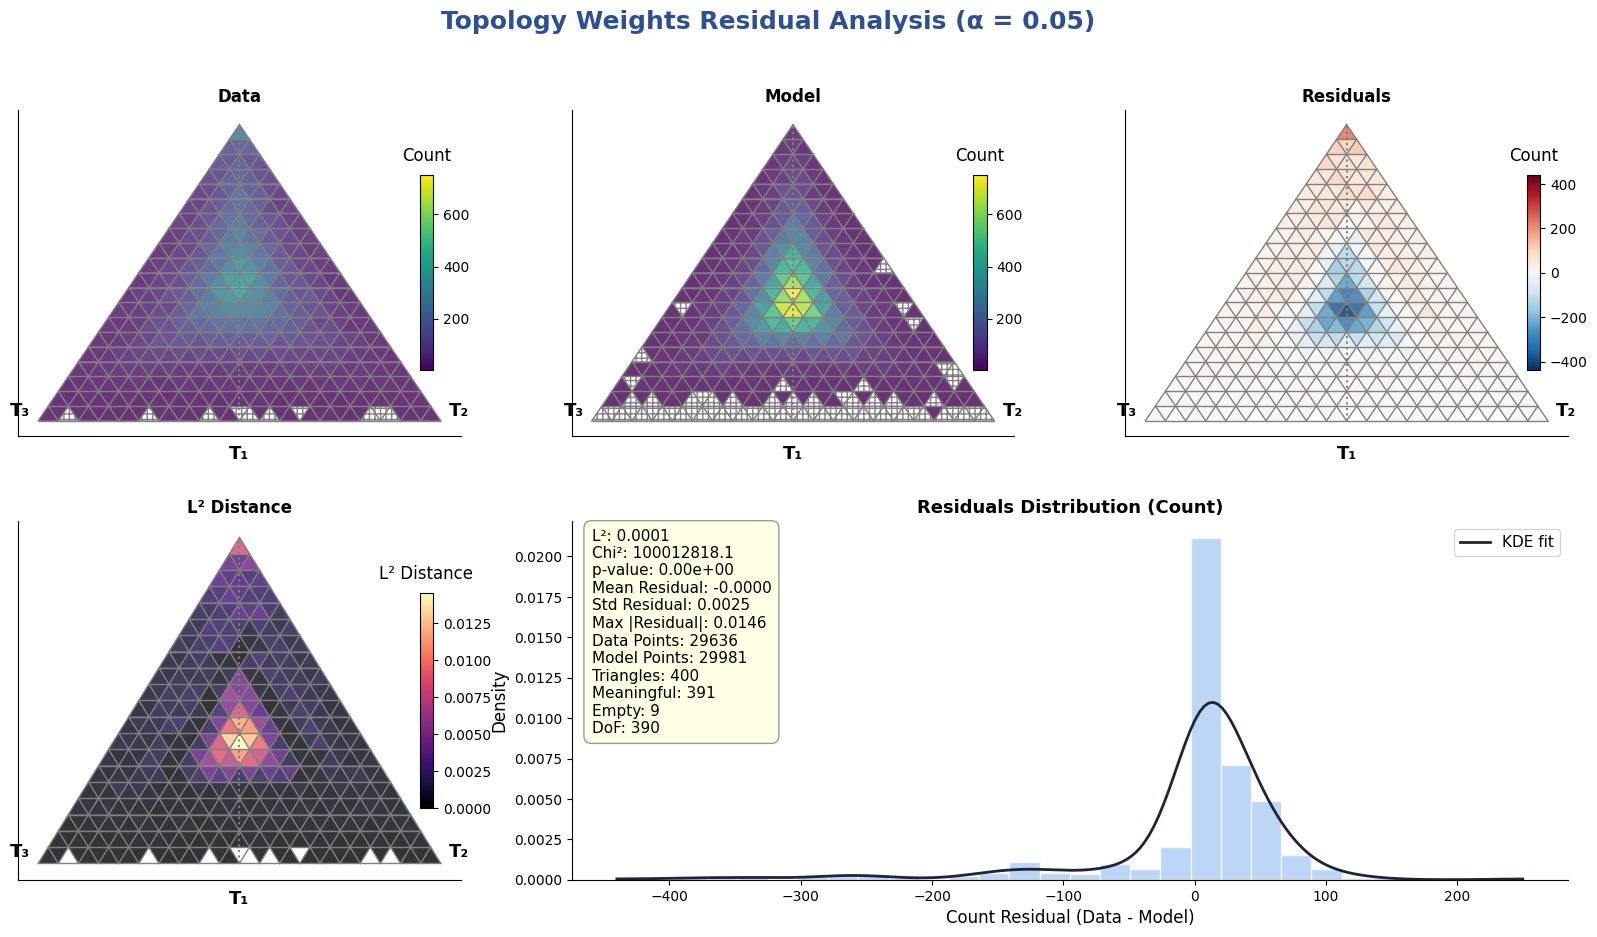


 2D Analysis complete!
 Results saved in: residual_results/
 Figure: analysis_analysis_granularity_0.05.png
 Data: analysis_results_granularity_0.05.csv
 Stats: analysis_statistics_granularity_0.05.txt


In [13]:
# RUN 2D RESIDUAL ANALYSIS
# ============================================================================

# Run the comprehensive analysis
fig_2d, results_df, statistics = run_comprehensive_analysis(
    data1=data1, 
    data2=data2, 
    alpha=GRANULARITY,
    output_dir=OUTPUT_DIR,
    compute_wasserstein=not SKIP_WASSERSTEIN
)

# Display the figure
plt.show()

print("\n 2D Analysis complete!")
print(f" Results saved in: {OUTPUT_DIR}/")
print(f" Figure: {OUTPUT_PREFIX}_analysis_granularity_{GRANULARITY}.png")
print(f" Data: {OUTPUT_PREFIX}_results_granularity_{GRANULARITY}.csv")
print(f" Stats: {OUTPUT_PREFIX}_statistics_granularity_{GRANULARITY}.txt")


## 2.  3D Visualization

**THIS SADLY DOESNT WORK: Controls:**
- **Mouse**: Left-click and drag to rotate, scroll to zoom, right-click and drag to pan
- **Keyboard**: Press 'h' in the plot window for help, 'r' to reset view, 's' to save, '1'-'4' for preset views


In [14]:
# 3D VISUALIZATION FUNCTIONS
# ============================================================================

class Interactive3DPlot:
    """Interactive 3D ternary plot with navigation controls."""
    
    def __init__(self, data, colormap=COLORMAP_3D, alpha=ALPHA_3D, figsize=FIGURE_SIZE_3D):
        self.data = data
        self.colormap = colormap
        self.alpha = alpha
        self.figsize = figsize
        self.fig = None
        self.ax = None
        self.current_view = 'default'
        
        # View presets
        self.view_presets = {
            'default': {'elev': 57, 'azim': -68},
            'top': {'elev': 90, 'azim': 0},
            'side1': {'elev': 0, 'azim': 0},
            'side2': {'elev': 0, 'azim': 90},
            'corner': {'elev': 30, 'azim': 45}
        }
        
        # Create the plot
        self.create_plot()
        self.setup_interactions()
        
    def create_plot(self):
        """Create the 3D plot with data."""
        print("🎨 Creating 3D histogram...")
        
        # Calculate histogram data
        triangles = create_triangular_grid_twiss(self.alpha)
        counts = []
        
        for triangle in triangles:
            (a1, b1), (a2, b2), (a3, b3) = triangle['T1'], triangle['T2'], triangle['T3']
            count = n_twisstcompare(a1, b1, a2, b2, a3, b3, self.data)
            counts.append(count)
        
        counts = np.array(counts)
        print(f"📊 Processed {len(triangles)} triangular bins")
        print(f"📈 Count range: {counts.min()} to {counts.max()}")
        
        # Create figure
        self.fig = plt.figure(figsize=self.figsize)
        self.ax = self.fig.add_subplot(111, projection='3d')
        
        # Style the plot
        self.ax.grid(False)
        self.ax.set_axis_off()
        for axis in [self.ax.xaxis, self.ax.yaxis, self.ax.zaxis]:
            axis.set_pane_color((1.0, 1.0, 1.0, 0.0))
            axis.line.set_color((1.0, 1.0, 1.0, 0.0))
        
        # Add labels
        self.ax.text(0, h, 0, "T₁", color="black", fontsize=18, weight="bold", ha="center", va="bottom")
        self.ax.text(-0.5, 0, 0, "T₂", color="black", fontsize=18, weight="bold", ha="right", va="top")
        self.ax.text(0.5, 0, 0, "T₃", color="black", fontsize=18, weight="bold", ha="left", va="top")
        
        # Setup colormap
        cmap = get_professional_colormap(self.colormap, truncate=False)
        norm = Normalize(vmin=counts[counts>0].min() if np.any(counts>0) else 0, vmax=counts.max())
        
        # Draw 3D bars
        for idx, triangle in enumerate(triangles):
            if counts[idx] == 0:
                continue
                
            (a1, b1), (a2, b2), (a3, b3) = triangle['T1'], triangle['T2'], triangle['T3']
            trianglex, triangley, _ = return_triangle_coord(a1, b1, a2, b2, a3, b3)
            z0 = 0
            z1 = counts[idx]
            
            # Create 3D prism
            vertices = []
            # Base triangle
            base = [(trianglex[i], triangley[i], z0) for i in range(3)]
            # Top triangle
            top = [(trianglex[i], triangley[i], z1) for i in range(3)]
            
            # Create faces
            faces = []
            # Base and top
            faces.append(base)
            faces.append(top)
            # Sides
            for i in range(3):
                face = [base[i], base[(i+1)%3], top[(i+1)%3], top[i]]
                faces.append(face)
            
            # Color based on height
            color = cmap(norm(z1))
            
            # Add to plot
            poly3d = Poly3DCollection(faces, alpha=0.8, facecolor=color, edgecolor='black', linewidth=0.1)
            self.ax.add_collection3d(poly3d)
        
        # Set initial view
        self.set_view('default')
        
        # Add title with instructions
        self.fig.suptitle('Interactive 3D Ternary Plot\\nMouse: Rotate/Zoom | Keys: r(reset), s(save), 1-4(views), h(help)', 
                         fontsize=12, y=0.95)
        
        print("✅ 3D plot created successfully!")
    
    def set_view(self, view_name):
        """Set predefined view angle."""
        if view_name in self.view_presets:
            view = self.view_presets[view_name]
            self.ax.view_init(elev=view['elev'], azim=view['azim'])
            self.current_view = view_name
            print(f"📐 View set to: {view_name} (elev={view['elev']}, azim={view['azim']})")
            if self.fig.canvas:
                self.fig.canvas.draw()
    
    def save_figure(self, filename=None):
        """Save current figure."""
        if filename is None:
            filename = f"interactive_3D_{self.current_view}.png"
        self.fig.savefig(filename, dpi=SAVE_HIGH_DPI, bbox_inches='tight')
        print(f"💾 Figure saved as: {filename}")
    
    def print_help(self):
        """Print help information."""
        help_text = f"""
🎮 INTERACTIVE 3D NAVIGATION CONTROLS:

Mouse Controls:
  • Left click + drag: Rotate the 3D view
  • Right click + drag: Pan the view  
  • Scroll wheel: Zoom in/out

Keyboard Shortcuts:
  • 'r': Reset to default view (elev=57, azim=-68)
  • 's': Save current figure
  • '1': Top view (looking down)
  • '2': Side view 1 
  • '3': Side view 2
  • '4': Corner view
  • 'h': Print this help

Current view: {self.current_view}
Current angles: elev={self.ax.elev:.1f}, azim={self.ax.azim:.1f}
        """
        print(help_text.strip())
    
    def on_key_press(self, event):
        """Handle keyboard events."""
        if event.key == 'r':
            self.set_view('default')
        elif event.key == 's':
            self.save_figure()
        elif event.key == '1':
            self.set_view('top')
        elif event.key == '2':
            self.set_view('side1')
        elif event.key == '3':
            self.set_view('side2')
        elif event.key == '4':
            self.set_view('corner')
        elif event.key == 'h':
            self.print_help()
    
    def setup_interactions(self):
        """Setup interactive controls."""
        # Connect keyboard events
        self.fig.canvas.mpl_connect('key_press_event', self.on_key_press)
        
        # Print initial help
        print("\n" + "="*60)
        print("🎮 INTERACTIVE 3D TERNARY PLOT READY!")
        print("="*60)
        self.print_help()
        print("="*60)
    
    def show(self):
        """Display the interactive plot."""
        return self.fig


def create_3d_visualization(data, title="3D Ternary Histogram"):
    """Create an interactive 3D visualization of ternary data."""
    print(f"🚀 Creating 3D visualization: {title}")
    plot3d = Interactive3DPlot(data, colormap=COLORMAP_3D, alpha=ALPHA_3D, figsize=FIGURE_SIZE_3D)
    return plot3d

print("3D visualization functions defined!")


3D visualization functions defined!


 Creating 3D visualization for Dataset 1: ne0.25
🚀 Creating 3D visualization: 3D Histogram - ne0.25
🎨 Creating 3D histogram...
📊 Processed 10000 triangular bins
📈 Count range: 0 to 26
📐 View set to: default (elev=57, azim=-68)
✅ 3D plot created successfully!

🎮 INTERACTIVE 3D TERNARY PLOT READY!
🎮 INTERACTIVE 3D NAVIGATION CONTROLS:

Mouse Controls:
  • Left click + drag: Rotate the 3D view
  • Right click + drag: Pan the view  
  • Scroll wheel: Zoom in/out

Keyboard Shortcuts:
  • 'r': Reset to default view (elev=57, azim=-68)
  • 's': Save current figure
  • '1': Top view (looking down)
  • '2': Side view 1 
  • '3': Side view 2
  • '4': Corner view
  • 'h': Print this help

Current view: default
Current angles: elev=57.0, azim=-68.0


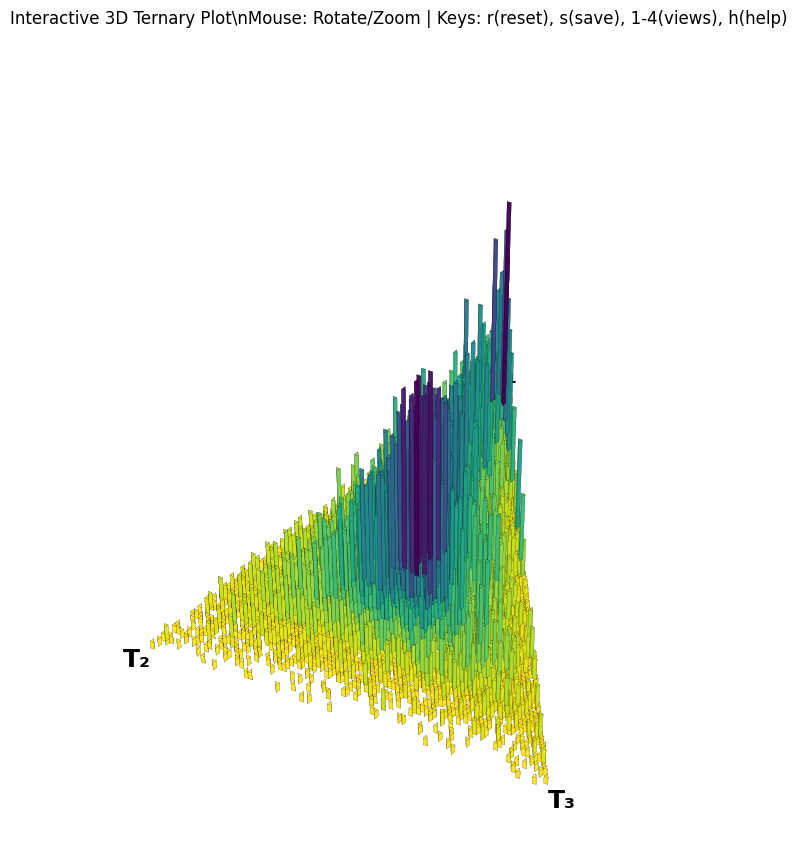

In [15]:
# ============================================================================
# (was supposed to be interactive) 3D PLOT - 
# ============================================================================
data_name = data1_name
data=data1
print(f" Creating 3D visualization for Dataset 1: {data_name}")

# Create 3D plot for data
plot3d = create_3d_visualization(data, title=f"3D Histogram - {data_name}")
fig_3d = plot3d.show()

# save
fig_3d.savefig("3d_histogram.pdf", format="pdf", bbox_inches="tight")
fig_3d.savefig("3d_histogram.svg", format="svg", bbox_inches="tight")
# for raster formats:
fig_3d.savefig("3d_histogram.png", dpi=300)

# print(f"✅ 3D plot ready! Click on the plot window and use mouse/keyboard controls.")
# print(" Try pressing 'h' in the plot window for help with controls!")


In [16]:
truth_file = Path("data_files/TRUTH_ne0.25.csv").resolve()
truth_file=dump_data(truth_file)


Attempting to read file: /home/hlifchit/Projects/Twisst_Yo/twisstntern_v2/Examples/data_files/TRUTH_ne0.25.csv

Trying delimiter: ','
  Skip 0 rows: Found 3 numeric columns
  Found 3 numeric columns with delimiter ',' skipping 0 rows

Using delimiter: ',', skipping 0 rows
Successfully read entire file

Data loaded and normalized. Points with T2 == T3 removed. Remaining rows: 29648


 ## 3. COMPARIOSN PLOTS

 ### **The experiments from Sean**

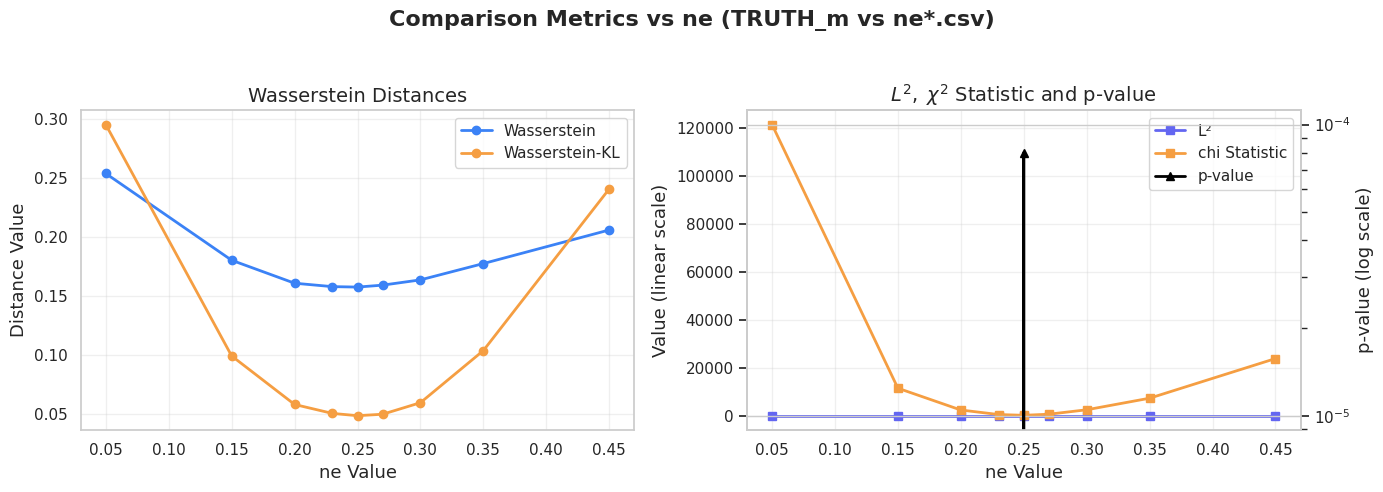

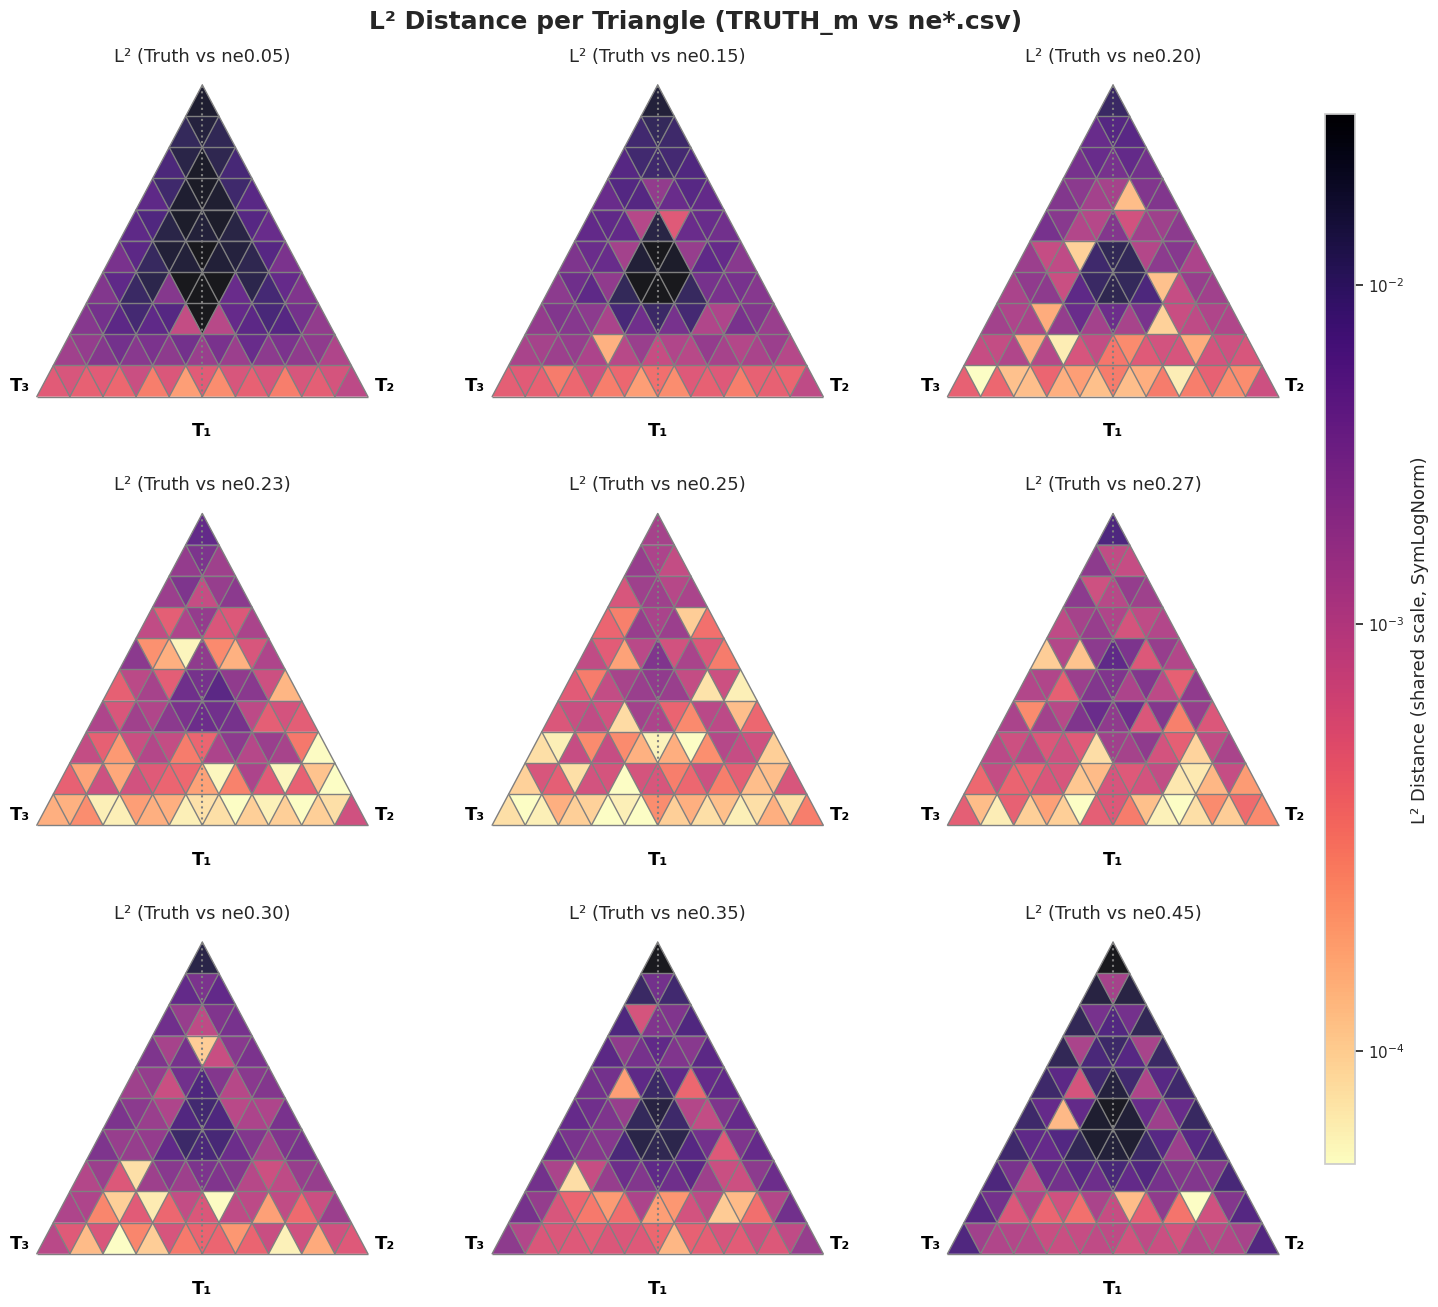

In [22]:
# --- PROFESSIONAL COMPARISON ANALYSIS: TRUTH vs NE FILES ---


sns.set_context('notebook')
sns.set_style('whitegrid')

alpha = 0.1
truth_file = Path("data_files/TRUTH_ne0.25.csv").resolve()
ne_directory = Path("data_files/").resolve()

# --- Suppress all output during metric and triangle calculations ---
class suppress_output:
    def __enter__(self):
        self._stdout = contextlib.redirect_stdout(io.StringIO())
        self._stderr = contextlib.redirect_stderr(io.StringIO())
        self._stdout.__enter__()
        self._stderr.__enter__()
    def __exit__(self, exc_type, exc_val, exc_tb):
        self._stdout.__exit__(exc_type, exc_val, exc_tb)
        self._stderr.__exit__(exc_type, exc_val, exc_tb)

# --- Load truth data ---
with suppress_output():
    #data1 = load_topology_data_twiss(truth_file)
    data1=dump_data(truth_file) 

# --- Find all ne*.csv files ---
ne_files = [f for f in os.listdir(ne_directory) if f.startswith("ne") and f.endswith(".csv")]
ne_files.sort()

# --- Initialize results storage ---
results = []
ternary_l2_arrays = []
ternary_results_dfs = []
ne_values = []

for ne_file in ne_files:
    ne_match = re.search(r'ne(\d+\.\d+)', ne_file)
    if ne_match:
        ne_value = float(ne_match.group(1))
    else:
        continue
    ne_file_path = os.path.join(ne_directory, ne_file)
    with suppress_output():
        #data2 = load_topology_data_twiss(ne_file_path)
        data2=dump_data(ne_file_path)
        metrics = compute_all_metrics(data1, data2, alpha=alpha)
        # For ternary L2 plot, get the results_df from perform_enhanced_grid_analysis
        results_df, _ = perform_enhanced_grid_analysis(data1, data2, alpha)
    # Store metrics
    results.append({
        'ne_value': ne_value,
        'filename': ne_file,
        'L_2': metrics['L2_distance'],
        'chi2': metrics['chi2_statistic'],
        'p_value': metrics['p_value'],
        'wasserstein': metrics['wasserstein_euclidean'],
        'wasserstein_kl': metrics['wasserstein_kl'],
    })
    # Store triangle L2 array for robust colorbar
    l2_per_triangle = np.sqrt(results_df['residual_squared'].values)
    ternary_l2_arrays.append(l2_per_triangle)
    ternary_results_dfs.append(results_df)
    ne_values.append(ne_value)

# --- Compute robust colorbar limits (1st/99th percentiles) ---
all_l2 = np.concatenate(ternary_l2_arrays)
vmin = np.nanpercentile(all_l2, 1)
vmax = np.nanpercentile(all_l2, 99)
# Use SymLogNorm for perceptual sensitivity (linear near zero, log elsewhere)
linthresh = max(1e-5, (vmax-vmin)/100)
norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)
cmap = plt.get_cmap(L2_COLORMAP_COMPARE)

# --- Convert results to DataFrame and sort by ne_value ---
results_df_n = pd.DataFrame(results).sort_values('ne_value')
ne_values_sorted = results_df_n['ne_value'].values

# --- Plot Wasserstein & Wasserstein-KL ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes
fig.suptitle('Comparison Metrics vs ne (TRUTH_m vs ne*.csv)', fontsize=16, fontweight='bold')

# --- Plot 1: Wasserstein distances ---
ax1.plot(results_df_n['ne_value'], results_df_n['wasserstein'], 'o-', label='Wasserstein', color='#3B82F6', linewidth=2)
ax1.plot(results_df_n['ne_value'], results_df_n['wasserstein_kl'], 'o-', label='Wasserstein-KL', color='#F59E42', linewidth=2)
ax1.set_xlabel('ne Value', fontsize=13)
ax1.set_ylabel('Distance Value', fontsize=13)
ax1.set_title('Wasserstein Distances', fontsize=14)
ax1.legend(frameon=True)
ax1.grid(True, alpha=0.3)

# --- Plot 2: L2, Chi2, and p-value (secondary y-axis) ---
ax2.plot(results_df_n['ne_value'], results_df_n['L_2'], 's-', label='L²', color='#6366F1', linewidth=2)
ax2.plot(results_df_n['ne_value'], results_df_n['chi2'], 's-', label='chi Statistic', color='#F59E42', linewidth=2)
ax2.set_xlabel('ne Value', fontsize=13)
ax2.set_ylabel('Value (linear scale)', fontsize=13)
ax2.set_title(r'$L^2$, $\,\chi^2$ Statistic and p-value', fontsize=14)
ax2.grid(True, alpha=0.3)

ax2b = ax2.twinx()
ax2b.plot(results_df_n['ne_value'], results_df_n['p_value'], '^-k', label='p-value', linewidth=2)
ax2b.set_yscale('log')
ax2b.set_ylabel('p-value (log scale)', fontsize=13)

# --- Legends ---
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- Grid of ternary L2 plots ---
import math
n_plots = len(ne_values)
ncols = 3
nrows = math.ceil(n_plots / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
fig.suptitle('L² Distance per Triangle (TRUTH_m vs ne*.csv)', fontsize=18, fontweight='bold', y=0.92)

for idx, (results_df_tri, ne_val) in enumerate(zip(ternary_results_dfs, ne_values)):
    row, col = divmod(idx, ncols)
    ax = axes[row, col] if nrows > 1 else axes[col]
    # --- Plot using the notebook's function, but override color normalization ---
    plot_ternary_base_twiss(ax, alpha)
    l2_per_triangle = np.sqrt(results_df_tri['residual_squared'].values)
    for i, row_df in results_df_tri.iterrows():
        has_data = (row_df['count_data'] > 0) or (row_df['count_model'] > 0)
        trianglex, triangley, _ = return_triangle_coord(
            row_df['T1_bounds'][0], row_df['T1_bounds'][1],
            row_df['T2_bounds'][0], row_df['T2_bounds'][1],
            row_df['T3_bounds'][0], row_df['T3_bounds'][1]
        )
        if not has_data:
            draw_empty_triangle(ax, trianglex, triangley, hatch=False)
        else:
            color = cmap(norm(l2_per_triangle[i]))
            ax.fill(trianglex, triangley, color=color, edgecolor='none', alpha=0.9)
    ax.set_title(f"L² (Truth vs ne{ne_val:.2f})", fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# Remove empty subplots
for idx in range(n_plots, nrows*ncols):
    row, col = divmod(idx, ncols)
    fig.delaxes(axes[row, col] if nrows > 1 else axes[col])

# --- Add a single colorbar for all ternary plots ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label('L² Distance (shared scale, SymLogNorm)', fontsize=13)

plt.subplots_adjust(left=0.05, right=0.9, top=0.88, bottom=0.08, wspace=0.25, hspace=0.25)
plt.show()

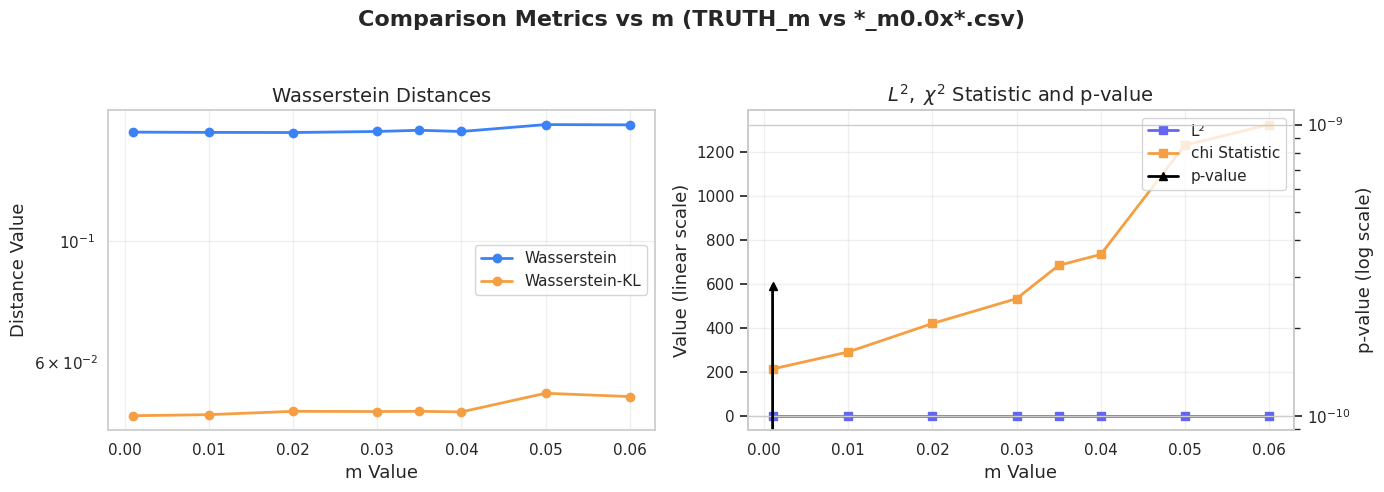

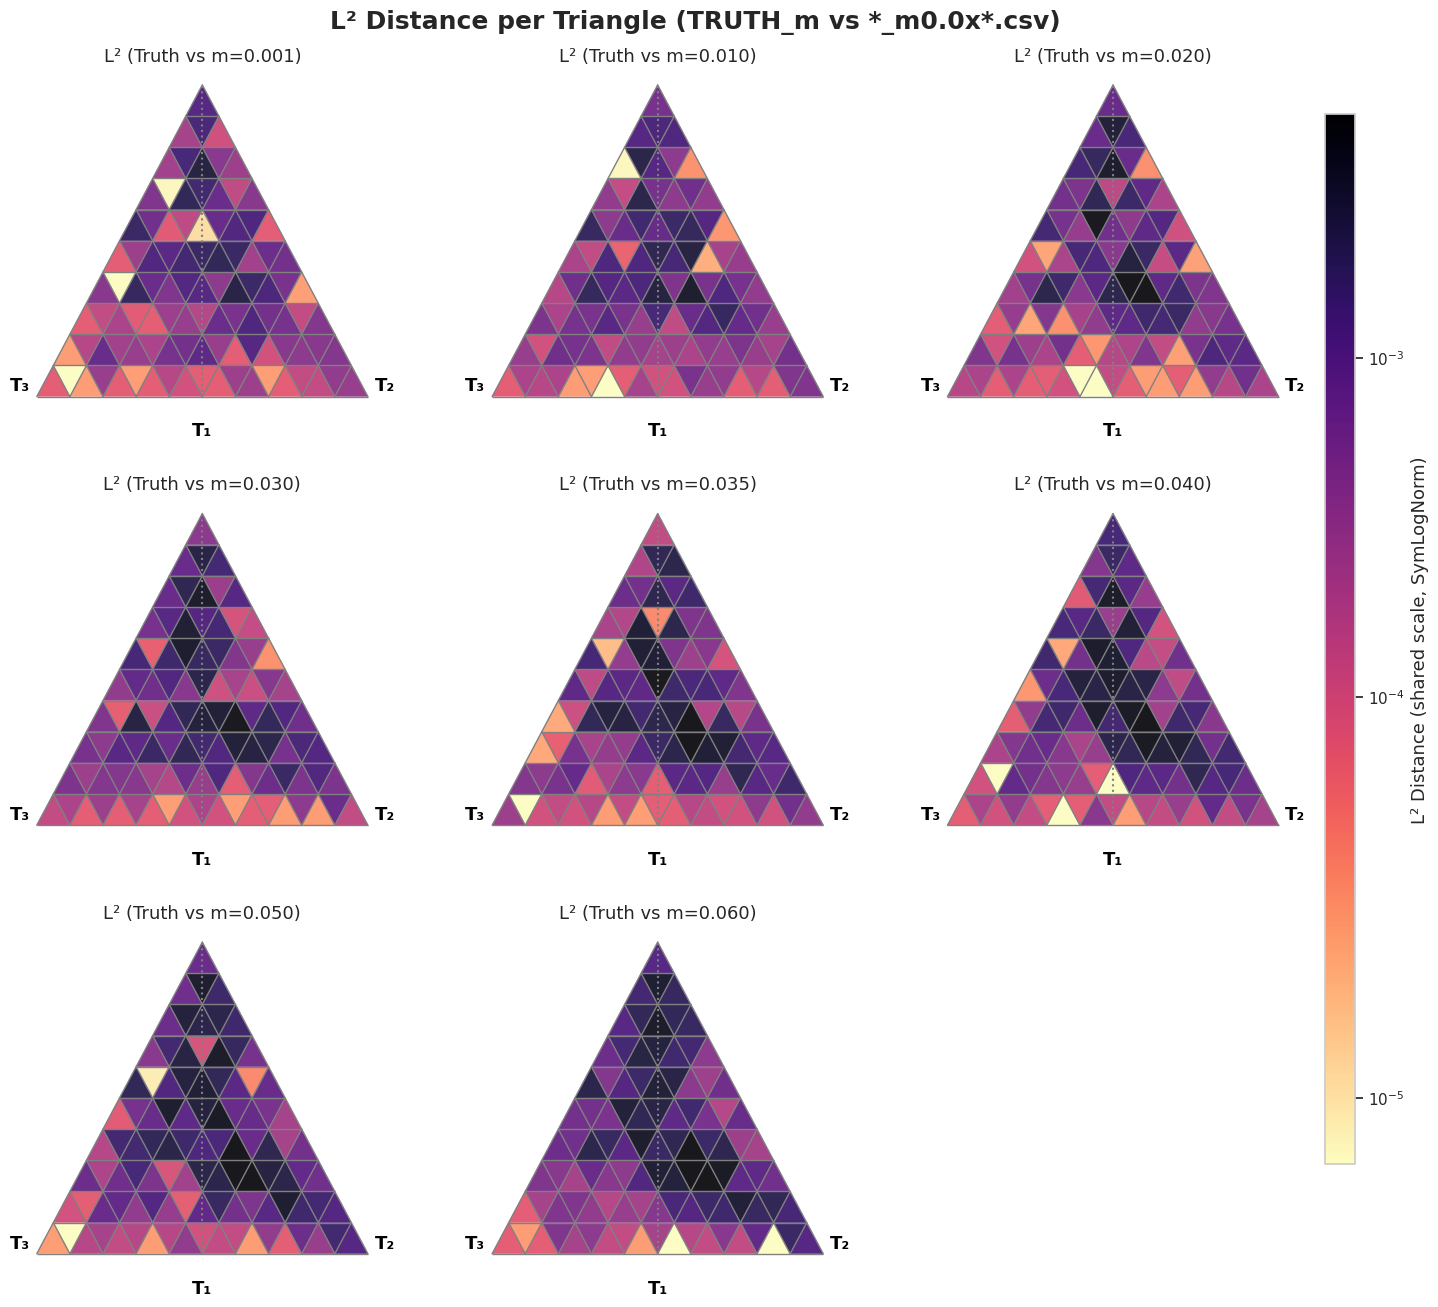

In [23]:
# --- PROFESSIONAL COMPARISON ANALYSIS: TRUTH vs *_m0.0x FILES ---


sns.set_context('notebook')
sns.set_style('whitegrid')

alpha = 0.1
truth_file = Path("data_files/TRUTH_m.csv").resolve()   
m_directory = Path("data_files/").resolve()

# --- Suppress all output during metric and triangle calculations ---
class suppress_output:
    def __enter__(self):
        self._stdout = contextlib.redirect_stdout(io.StringIO())
        self._stderr = contextlib.redirect_stderr(io.StringIO())
        self._stdout.__enter__()
        self._stderr.__enter__()
    def __exit__(self, exc_type, exc_val, exc_tb):
        self._stdout.__exit__(exc_type, exc_val, exc_tb)
        self._stderr.__exit__(exc_type, exc_val, exc_tb)

# --- Load truth data ---
with suppress_output():
    #data1 = load_topology_data_twiss(truth_file)
    data2=dump_data(ne_file_path)

# --- Find all *_m0.0x*.csv files ---
m_files = [f for f in os.listdir(m_directory) if re.search(r'_m0\.\d+', f) and f.endswith('.csv')]
m_files.sort()

# --- Initialize results storage ---
results = []
ternary_l2_arrays = []
ternary_results_dfs = []
m_values = []

for m_file in m_files:
    m_match = re.search(r'_m0\.(\d+)', m_file)
    if m_match:
        m_value = float('0.' + m_match.group(1))
    else:
        continue
    m_file_path = os.path.join(m_directory, m_file)
    with suppress_output():
        #data2 = load_topology_data_twiss(m_file_path)
        data2=dump_data(m_file_path)
        metrics = compute_all_metrics(data1, data2, alpha=alpha)
        results_df, _ = perform_enhanced_grid_analysis(data1, data2, alpha)
    results.append({
        'm_value': m_value,
        'filename': m_file,
        'L_2': metrics['L2_distance'],
        'chi2': metrics['chi2_statistic'],
        'p_value': metrics['p_value'],
        'wasserstein': metrics['wasserstein_euclidean'],
        'wasserstein_kl': metrics['wasserstein_kl'],
    })
    l2_per_triangle = np.sqrt(results_df['residual_squared'].values)
    ternary_l2_arrays.append(l2_per_triangle)
    ternary_results_dfs.append(results_df)
    m_values.append(m_value)

# --- Compute robust colorbar limits (1st/99th percentiles) ---
all_l2 = np.concatenate(ternary_l2_arrays)
vmin = np.nanpercentile(all_l2, 1)
vmax = np.nanpercentile(all_l2, 99)
linthresh = max(1e-5, (vmax-vmin)/100)
norm = SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)
cmap = plt.get_cmap(L2_COLORMAP_COMPARE)

# --- Convert results to DataFrame and sort by m_value ---
results_df_m = pd.DataFrame(results).sort_values('m_value')
m_values_sorted = results_df_m['m_value'].values

# --- Plot Wasserstein & Wasserstein-KL ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax1, ax2 = axes
fig.suptitle('Comparison Metrics vs m (TRUTH_m vs *_m0.0x*.csv)', fontsize=16, fontweight='bold')

# --- Plot 1: Wasserstein distances ---
ax1.plot(results_df_m['m_value'], results_df_m['wasserstein'], 'o-', label='Wasserstein', color='#3B82F6', linewidth=2)
ax1.plot(results_df_m['m_value'], results_df_m['wasserstein_kl'], 'o-', label='Wasserstein-KL', color='#F59E42', linewidth=2)
ax1.set_xlabel('m Value', fontsize=13)
ax1.set_yscale('log')
ax1.set_ylabel('Distance Value', fontsize=13)
ax1.set_title('Wasserstein Distances', fontsize=14)
ax1.legend(frameon=True)
ax1.grid(True, alpha=0.3)

# --- Plot 2: L2, Chi2, and p-value (secondary y-axis) ---
ax2.plot(results_df_m['m_value'], results_df_m['L_2'], 's-', label='L²', color='#6366F1', linewidth=2)
ax2.plot(results_df_m['m_value'], results_df_m['chi2'], 's-', label='chi Statistic', color='#F59E42', linewidth=2)
ax2.set_xlabel('m Value', fontsize=13)
ax2.set_ylabel('Value (linear scale)', fontsize=13)
ax2.set_title(r'$L^2$, $\,\chi^2$ Statistic and p-value', fontsize=14)
ax2.grid(True, alpha=0.3)

ax2b = ax2.twinx()
ax2b.plot(results_df_m['m_value'], results_df_m['p_value'], '^-k', label='p-value', linewidth=2)
ax2b.set_yscale('log')
ax2b.set_ylabel('p-value (log scale)', fontsize=13)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# --- Grid of ternary L2 plots ---
import math
n_plots = len(m_values)
ncols = 3
nrows = math.ceil(n_plots / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
fig.suptitle('L² Distance per Triangle (TRUTH_m vs *_m0.0x*.csv)', fontsize=18, fontweight='bold', y=0.92)

for idx, (results_df_tri, m_val) in enumerate(zip(ternary_results_dfs, m_values)):
    row, col = divmod(idx, ncols)
    ax = axes[row, col] if nrows > 1 else axes[col]
    plot_ternary_base_twiss(ax, alpha)
    l2_per_triangle = np.sqrt(results_df_tri['residual_squared'].values)
    for i, row_df in results_df_tri.iterrows():
        has_data = (row_df['count_data'] > 0) or (row_df['count_model'] > 0)
        trianglex, triangley, _ = return_triangle_coord(
            row_df['T1_bounds'][0], row_df['T1_bounds'][1],
            row_df['T2_bounds'][0], row_df['T2_bounds'][1],
            row_df['T3_bounds'][0], row_df['T3_bounds'][1]
        )
        if not has_data:
            draw_empty_triangle(ax, trianglex, triangley, hatch=False)
        else:
            color = cmap(norm(l2_per_triangle[i]))
            ax.fill(trianglex, triangley, color=color, edgecolor='none', alpha=0.9)
    ax.set_title(f"L² (Truth vs m={m_val:.3f})", fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

for idx in range(n_plots, nrows*ncols):
    row, col = divmod(idx, ncols)
    fig.delaxes(axes[row, col] if nrows > 1 else axes[col])

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = plt.colorbar(sm, cax=cbar_ax)
cbar.set_label('L² Distance (shared scale, SymLogNorm)', fontsize=13)

plt.subplots_adjust(left=0.05, right=0.9, top=0.88, bottom=0.08, wspace=0.25, hspace=0.25)
plt.show()


## 1.B RESIDUAL PLOT 2.0

In [24]:
def plot_composite_comparison(
    results_df, statistics, alpha,
    all_ne_results_df,  # DataFrame with columns ['ne_value', 'L_2'] for all ne*.csv vs TRUTH
    #ternary_results_df, # DataFrame from perform_enhanced_grid_analysis(data1, data2, alpha)
    ne_label="ne0.15", truth_label="TRUTH_ne0.25"
):
    """
    Plots a 2x3 grid:
    Row 1: Ternary plot for data1 | Ternary plot for data2
    Row 2: Residuals plot         | L2 per triangle plot
    Row 3: Residuals histogram    | L2 values for all ne*.csv vs TRUTH (line plot, no chi2/p-value)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import seaborn as sns
    from matplotlib.colors import Normalize
    from scipy.stats import gaussian_kde

    # --- Setup figure and axes ---
    fig, axes = plt.subplots(3, 2, figsize=(14, 18))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    ax = axes  # alias


#############################
    # --- Row 1: Ternary plots with SHARED color scale ---
    from matplotlib import cm
    from matplotlib.colors import Normalize

    # Compute global vmin/vmax across both datasets
    cmap_counts = plt.get_cmap(DATA_MODEL_COLORMAP)
    vmin_counts = 1  # or 0 if you want to include zeros
    vmax_counts = max(results_df['count_data'].max(),
                    results_df['count_model'].max())
    norm_counts = Normalize(vmin=vmin_counts, vmax=vmax_counts)

    # Plot first ternary (data) without creating its own colorbar
    plot_ternary_with_colorbar(
        ax[0, 0], results_df, alpha,
        'count_data', f'{truth_label}',
        vmin=vmin_counts, vmax=vmax_counts,
        cmap=cmap_counts,
        cbar_label=None  # suppress internal colorbar if helper supports it
    )

    # Plot second ternary (model) with the same normalization and no colorbar
    plot_ternary_with_colorbar(
        ax[0, 1], results_df, alpha,
        'count_model', f'{ne_label}',
        vmin=vmin_counts, vmax=vmax_counts,
        cmap=cmap_counts,
        cbar_label=None
    )

    # Add one shared colorbar for both ternary plots
    sm_counts = cm.ScalarMappable(norm=norm_counts, cmap=cmap_counts)
    sm_counts.set_array([])  # needed for matplotlib <3.6
    cbar_top = fig.colorbar(sm_counts, ax=[ax[0, 0], ax[0, 1]],
                            fraction=0.046, pad=0.04)
    cbar_top.set_label("Count", fontsize=12)





############################33
    # --- Row 1: Ternary plots ---
    # Data1
    plot_ternary_with_colorbar(
        ax[0, 0], results_df, alpha, 'count_data', f'{ne_label}', 
        vmin=1, vmax=results_df['count_data'].max(), 
        cmap=plt.get_cmap(DATA_MODEL_COLORMAP), cbar_label="Count"
    )
    # Data2
    plot_ternary_with_colorbar(
        ax[0, 1], results_df, alpha, 'count_model', f'{truth_label}', 
        vmin=1, vmax=results_df['count_model'].max(), 
        cmap=plt.get_cmap(DATA_MODEL_COLORMAP), cbar_label="Count"
    )

    # --- Calculate l2 distance per triangle and add to DataFrame ---
    if 'l2' not in results_df.columns:
        results_df['l2'] = np.sqrt(results_df['residual_squared'])

    # --- Row 2: Residuals and L2 per triangle ---

    # --- Residuals plot (left) ---
    plot_heatmap_data_twiss(ax[1, 0], results_df, alpha, 'count_residual', 'Residuals')

    # Add a colorbar manually with centered diverging colormap
    vmax_resid = results_df['count_residual'].abs().max()
    norm_resid = Normalize(vmin=-vmax_resid, vmax=vmax_resid)
    cmap_resid = sns.color_palette(RESIDUALS_COLORMAP, as_cmap=True)  # or 'RdBu_r'
    cax_resid = inset_axes(ax[1, 0], width="3%", height="60%", loc='right', borderpad=2)
    cb_resid = plt.colorbar(cm.ScalarMappable(norm=norm_resid, cmap=cmap_resid), cax=cax_resid)
    cb_resid.ax.set_title("Count", fontsize=11)

    # --- L2 plot (right) ---
    plot_heatmap_data_twiss(ax[1, 1], results_df, alpha, 'l2', 'L² Distance')

    # Colorbar for L²
    vmax_l2 = results_df['l2'].max()
    vmin_l2 = 1 if vmax_l2 > 1 else 0
    norm_l2 = Normalize(vmin=vmin_l2, vmax=vmax_l2)
    cmap_l2 = plt.get_cmap(L2_COLORMAP)  # or any colormap you like
    cax_l2 = inset_axes(ax[1, 1], width="3%", height="60%", loc='right', borderpad=2)
    cb_l2 = plt.colorbar(cm.ScalarMappable(norm=norm_l2, cmap=cmap_l2), cax=cax_l2)
    cb_l2.ax.set_title(r"$L^2$", fontsize=11)

    # --- Row 3: Residuals histogram and L2 line plot ---
    meaningful_triangles = (results_df['count_data'] > 0) | (results_df['count_model'] > 0)
    residuals = results_df.loc[meaningful_triangles, 'count_residual'].values
    ax[2, 0].hist(residuals, bins=30, color=HISTOGRAM_COLOR, alpha=0.7, edgecolor='white', density=True)
    if len(residuals) > 1:
        x_grid = np.linspace(residuals.min(), residuals.max(), 200)
        kde = gaussian_kde(residuals)
        ax[2, 0].plot(x_grid, kde(x_grid), color=KDE_COLOR, linewidth=2, label="KDE fit")
    ax[2, 0].set_title('Residuals Distribution (Count)', fontsize=13, fontweight='bold')
    ax[2, 0].set_xlabel('Count Residual (Data - Model)', fontsize=12)
    ax[2, 0].set_ylabel('Density', fontsize=12)
    if len(residuals) > 1:
        ax[2, 0].legend(loc='upper right', fontsize=11)
    sns.despine(ax=ax[2, 0])

    # L2 line plot for all ne*.csv vs TRUTH
    ax[2, 1].plot(all_ne_results_df['ne_value'], all_ne_results_df['L_2'], 's-', color='#6366F1', linewidth=2)
    ax[2, 1].set_xlabel('ne Value', fontsize=13)
    ax[2, 1].set_ylabel('L² Distance', fontsize=13)
    ax[2, 1].set_title(r'$L^2$ Distance: all ne vs TRUTH', fontsize=14)
    ax[2, 1].grid(True, alpha=0.3)

    # --- Final touches ---
    fig.suptitle(f'Composite Comparison: {ne_label} vs {truth_label}', fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    return fig



In [25]:
alpha = 0.05
#data1= dump_data("/home/hlifchit/projects/twissting_baby/Examples/data_files/TRUTH_ne0.25.csv")
#data2= dump_data("/home/hlifchit/projects/twissting_baby/Examples/data_files/ne0.15.csv")
results_df, statistics =  perform_enhanced_grid_analysis(data1, data2, alpha)  
all_ne_results = results_df_n

🔬 Performing grid analysis with α = 0.05
📐 Created 400 triangular bins

📊 COMPREHENSIVE GRID-BASED METRICS
L² Distance:              0.000029
χ² Statistic:             2400002186.285155
χ² p-value:               0.000000e+00
Mean proportional residual: -0.000000
Std proportional residual:  0.000585
Max |proportional residual|: 0.002828
Mean squared residual:    0.000000
Data Points:              29648
Model Points:             29669
Grid Triangles (Total):   400
Meaningful Triangles:     398
Empty Triangles:          2
Degrees of Freedom:       397


In [ ]:


if 'l2' not in results_df.columns:
    results_df['l2'] = np.sqrt(results_df['residual_squared'])

results_df

,T1_bounds,T2_bounds,T3_bounds,count_data,count_model,prop_data,prop_model,prop_residual,residual_squared,count_residual,l2
0,"(0.0, 0.05)","(0.0, 0.05)","(0.95, 1.0)",7,0,0.000236,0.000000,0.000236,5.574492e-08,7,0.000236
1,"(0.0, 0.05)","(0.0, 0.05)","(0.9, 0.95)",3,0,0.000101,0.000000,0.000101,1.023886e-08,3,0.000101
2,"(0.0, 0.05)","(0.05, 0.1)","(0.9, 0.95)",2,0,0.000067,0.000000,0.000067,4.550605e-09,2,0.000067
3,"(0.0, 0.05)","(0.05, 0.1)","(0.85, 0.9)",1,0,0.000034,0.000000,0.000034,1.137651e-09,1,0.000034
4,"(0.0, 0.05)","(0.1, 0.15)","(0.85, 0.9)",4,0,0.000135,0.000000,0.000135,1.820242e-08,4,0.000135
...,...,...,...,...,...,...,...,...,...,...,...
395,"(0.85, 0.9)","(0.1, 0.15)","(0.0, 0.05)",100,14,0.003373,0.000467,0.002906,8.444524e-06,86,0.002906
396,"(0.9, 0.95)","(0.0, 0.05)","(0.05, 0.1)",144,15,0.004857,0.000500,0.004357,1.898059e-05,129,0.004357
397,"(0.9, 0.95)","(0.0, 0.05)","(0.0, 0.05)",120,33,0.004047,0.001101,0.002947,8.683592e-06,87,0.002947
398,"(0.9, 0.95)","(0.05, 0.1)","(0.0, 0.05)",131,18,0.004419,0.000600,0.003818,1.457812e-05,113,0.003818


In [26]:
all_ne_results

,ne_value,filename,L_2,chi2,p_value,wasserstein,wasserstein_kl
0,0.05,ne0.05.csv,0.003342,121376.305953,0.00000,0.253875,0.295327
1,0.15,ne0.15.csv,0.000922,11456.954511,0.00000,0.180349,0.099251
2,0.20,ne0.20.csv,0.000392,2368.989942,0.00000,0.160885,0.058117
3,0.23,ne0.23.csv,0.000160,485.528997,0.00000,0.157992,0.050552
4,0.25,ne0.25.csv,0.000081,161.132771,0.00008,0.157613,0.048601
5,0.27,ne0.27.csv,0.000163,621.504999,0.00000,0.159260,0.049843
6,0.30,ne0.30.csv,0.000341,2464.952936,0.00000,0.163709,0.059625
7,0.35,ne0.35.csv,0.000582,7293.131535,0.00000,0.177546,0.103792
8,0.45,ne0.45.csv,0.000987,23822.338221,0.00000,0.206008,0.240805


In [29]:
################### TRY 22.9 - 2

def plot_composite_comparison(
    results_df, statistics, alpha,
    all_ne_results_df,
    ne_label="ne0.05", truth_label="TRUTH_ne0.25"
):
    """
    Composite plot with TWO identical count colorbars (one next to each top ternary),
    using a SHARED normalization (same vmin/vmax). Also draws a red dashed line at ne=0.25
    on the L² line plot.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib import cm
    from matplotlib.colors import Normalize
    from matplotlib.patches import Polygon
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from scipy.stats import gaussian_kde

    # Defaults if not defined in the global scope
    g = globals()
    DATA_MODEL_COLORMAP = g.get("DATA_MODEL_COLORMAP", "viridis")
    RESIDUALS_COLORMAP = g.get("RESIDUALS_COLORMAP", "RdBu_r")
    L2_COLORMAP = g.get("L2_COLORMAP", "magma")
    HATCH_PATTERN = g.get("HATCH_PATTERN", "//")
    HATCH_DATA = g.get("HATCH_DATA", True)
    HATCH_RESIDUALS = g.get("HATCH_RESIDUALS", True)
    HATCH_L2 = g.get("HATCH_L2", True)
    HISTOGRAM_COLOR = g.get("HISTOGRAM_COLOR", "#9CA3AF")
    KDE_COLOR = g.get("KDE_COLOR", "#111827")

    # ---------- helpers ----------
    def draw_empty_triangle(ax, trianglex, triangley, hatch=True):
        tri = Polygon(list(zip(trianglex, triangley)), closed=True,
                      facecolor='white',
                      edgecolor='grey' if hatch else 'none',
                      hatch=HATCH_PATTERN if hatch else None,
                      linewidth=0.5 if hatch else 0)
        ax.add_patch(tri)

    def plot_ternary_base_twiss(ax, alpha):
        x_side_T2 = np.linspace(0, 0.5, 100)
        x_side_T3 = np.linspace(-0.5, 0, 100)
        ax.plot(x_side_T2, T2(0, x_side_T2), color="grey", lw=1)
        ax.plot(x_side_T3, T3(0, x_side_T3), color="grey", lw=1)
        ax.hlines(y=0, xmin=-0.5, xmax=0.5, color="grey", lw=1)
        ax.set_xticks([]); ax.set_yticks([])
        for i in range(1, int(1/alpha)):
            y = i * alpha
            ax.hlines(y=y*h, xmin=T1_lim(y)[0], xmax=T1_lim(y)[1], color="grey", lw=1)
            x2 = np.linspace(T2_lim(y)[0], T2_lim(y)[1], 100)
            ax.plot(x2, T2(y, x2), color="grey", lw=1)
            x3 = np.linspace(T3_lim(y)[0], T3_lim(y)[1], 100)
            ax.plot(x3, T3(y, x3), color="grey", lw=1)
        ax.vlines(x=0, ymin=0, ymax=h, colors="grey", ls=':')
        ax.text(0, -0.07, 'T₁', size=13, fontweight='bold', ha='center', va='top')
        ax.text(0.52, 0.03, 'T₂', size=13, fontweight='bold', ha='left', va='center')
        ax.text(-0.52, 0.03, 'T₃', size=13, fontweight='bold', ha='right', va='center')
        for s in ax.spines.values(): s.set_visible(False)

    def plot_heatmap_data_twiss(ax, df, alpha, data_type, title, cmap, norm=None,
                                vmin=None, vmax=None):
        """
        Index-safe ternary heatmap. If `norm` is provided, it is used verbatim.
        """
        plot_ternary_base_twiss(ax, alpha)

        # choose value vector and empty logic
        if data_type == 'count_residual':
            vals = df['count_residual'].to_numpy()
            empty_logic = lambda r: (r['count_data']==0 and r['count_model']==0)
            if norm is None:
                vmax_local = np.abs(vals).max() if vmax is None else vmax
                vmin_local = -vmax_local if vmin is None else vmin
                norm = Normalize(vmin=vmin_local, vmax=vmax_local)
        elif data_type == 'l2':
            vals = np.sqrt(df['residual_squared'].to_numpy())
            empty_logic = lambda r: (r['count_data']==0 and r['count_model']==0)
            if norm is None:
                vmax_local = vals.max() if vmax is None else vmax
                vmin_local = (1 if vmax_local>1 else 0) if vmin is None else vmin
                norm = Normalize(vmin=vmin_local, vmax=vmax_local)
        else:  # 'count_data' or 'count_model' (or fallback)
            vals = df[data_type].to_numpy()
            empty_logic = lambda r: (r[data_type]==0)
            if norm is None:
                vmax_local = vals.max() if vmax is None else vmax
                vmin_local = (1 if vmax_local>1 else vals.min()) if vmin is None else vmin
                norm = Normalize(vmin=vmin_local, vmax=vmax_local)

        # draw triangles (index-safe)
        df_reset = df.reset_index(drop=True)
        for idx, row in df_reset.iterrows():
            xtri, ytri, _ = return_triangle_coord(
                row['T1_bounds'][0], row['T1_bounds'][1],
                row['T2_bounds'][0], row['T2_bounds'][1],
                row['T3_bounds'][0], row['T3_bounds'][1]
            )
            if empty_logic(row):
                draw_empty_triangle(ax, xtri, ytri, hatch=True)
            else:
                ax.fill(xtri, ytri, color=cmap(norm(vals[idx])),
                        edgecolor='none', alpha=0.8)

        ax.set_title(title, fontsize=12, fontweight='bold')
        sns.despine(ax=ax)
        return norm

    # ---------- figure ----------
    fig, axes = plt.subplots(3, 2, figsize=(14,18))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    ax = axes

    # --- Row 1: two ternaries with SAME normalization and TWO identical colorbars ---
    cmap_counts = plt.get_cmap(DATA_MODEL_COLORMAP)
    vmin_counts = 1  # set to 0 if you want zeros included
    vmax_counts = max(results_df['count_data'].max(), results_df['count_model'].max())
    norm_counts = Normalize(vmin=vmin_counts, vmax=vmax_counts)  # shared norm

    # left plot
    plot_heatmap_data_twiss(ax[0,0], results_df, alpha, 'count_data', f'{truth_label}',
                            cmap=cmap_counts, norm=norm_counts)
    cax1 = inset_axes(ax[0,0], width="3%", height="60%", loc='right', borderpad=2)
    cb1 = plt.colorbar(cm.ScalarMappable(norm=norm_counts, cmap=cmap_counts), cax=cax1)
    cb1.ax.set_title("Count", fontsize=11)

    # right plot
    plot_heatmap_data_twiss(ax[0,1], results_df, alpha, 'count_model', f'{ne_label}',
                            cmap=cmap_counts, norm=norm_counts)
    cax2 = inset_axes(ax[0,1], width="3%", height="60%", loc='right', borderpad=2)
    cb2 = plt.colorbar(cm.ScalarMappable(norm=norm_counts, cmap=cmap_counts), cax=cax2)
    cb2.ax.set_title("Count", fontsize=11)

    # --- Row 2: residuals (centered) and L² ---
    cmap_resid = sns.color_palette(RESIDUALS_COLORMAP, as_cmap=True)
    vmax_resid = results_df['count_residual'].abs().max()
    norm_resid = Normalize(vmin=-vmax_resid, vmax=vmax_resid)
    plot_heatmap_data_twiss(ax[1,0], results_df, alpha, 'count_residual', 'Residuals',
                            cmap=cmap_resid, norm=norm_resid)
    cax_resid = inset_axes(ax[1,0], width="3%", height="60%", loc='right', borderpad=2)
    plt.colorbar(cm.ScalarMappable(norm=norm_resid, cmap=cmap_resid), cax=cax_resid)

    if 'l2' not in results_df.columns:
        results_df['l2'] = np.sqrt(results_df['residual_squared'])
    cmap_l2 = plt.get_cmap(L2_COLORMAP)
    vmax_l2 = results_df['l2'].max()
    vmin_l2 = 1 if vmax_l2>1 else 0
    norm_l2 = Normalize(vmin=vmin_l2, vmax=vmax_l2)
    plot_heatmap_data_twiss(ax[1,1], results_df, alpha, 'l2', 'L² Distance',
                            cmap=cmap_l2, norm=norm_l2)
    cax_l2 = inset_axes(ax[1,1], width="3%", height="60%", loc='right', borderpad=2)
    plt.colorbar(cm.ScalarMappable(norm=norm_l2, cmap=cmap_l2), cax=cax_l2)

    # --- Row 3: residuals histogram & L² vs ne (with vertical red line at 0.25) ---
    meaningful = (results_df['count_data']>0)|(results_df['count_model']>0)
    residuals = results_df.loc[meaningful,'count_residual'].to_numpy()
    ax[2,0].hist(residuals, bins=30, color=HISTOGRAM_COLOR, alpha=0.7,
                 edgecolor='white', density=True)
    if residuals.size>1:
        xg = np.linspace(residuals.min(), residuals.max(),200)
        kde = gaussian_kde(residuals)
        ax[2,0].plot(xg, kde(xg), color=KDE_COLOR, lw=2, label='KDE fit')
        ax[2,0].legend(loc='upper right', fontsize=11)
    ax[2,0].set_title('Residuals Distribution (Count)', fontsize=13, fontweight='bold')
    ax[2,0].set_xlabel('Count Residual (Data - Model)'); ax[2,0].set_ylabel('Density')
    sns.despine(ax=ax[2,0])

    ax[2,1].plot(all_ne_results_df['ne_value'], all_ne_results_df['L_2'],
                 's-', color='#6366F1', lw=2)
    ax[2,1].axvline(0.25, color='red', ls='--', lw=2, label='ne=0.25')
    ax[2,1].legend()
    ax[2,1].set_xlabel('ne Value'); ax[2,1].set_ylabel('L² Distance')
    ax[2,1].set_title(r'$L^2$ Distance: all ne vs TRUTH')
    ax[2,1].grid(True, alpha=0.3)
    sns.despine(ax=ax[2,1])

    # --- final touches ---
    fig.suptitle(f'Composite Comparison: {ne_label} vs {truth_label}',
                 fontsize=20, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0,0,1,0.97])
    plt.show()
    return fig


In [36]:
data1

,T1,T2,T3
0,0.393472,0.088448,0.518080
1,0.383846,0.523789,0.092365
2,0.755840,0.188160,0.056000
3,0.778432,0.138624,0.082944
4,0.513344,0.264768,0.221888
...,...,...,...
29995,0.469440,0.463936,0.066624
29996,0.648128,0.111616,0.240256
29997,0.718784,0.120576,0.160640
29998,0.499126,0.233626,0.267249


🔬 Performing grid analysis with α = 0.05
📐 Created 400 triangular bins

📊 COMPREHENSIVE GRID-BASED METRICS
L² Distance:              0.000124
χ² Statistic:             12829.616246
χ² p-value:               0.000000e+00
Mean proportional residual: -0.000000
Std proportional residual:  0.002510
Max |proportional residual|: 0.014808
Mean squared residual:    0.000006
Data Points:              29648
Model Points:             29981
Grid Triangles (Total):   400
Meaningful Triangles:     393
Empty Triangles:          7
Degrees of Freedom:       392


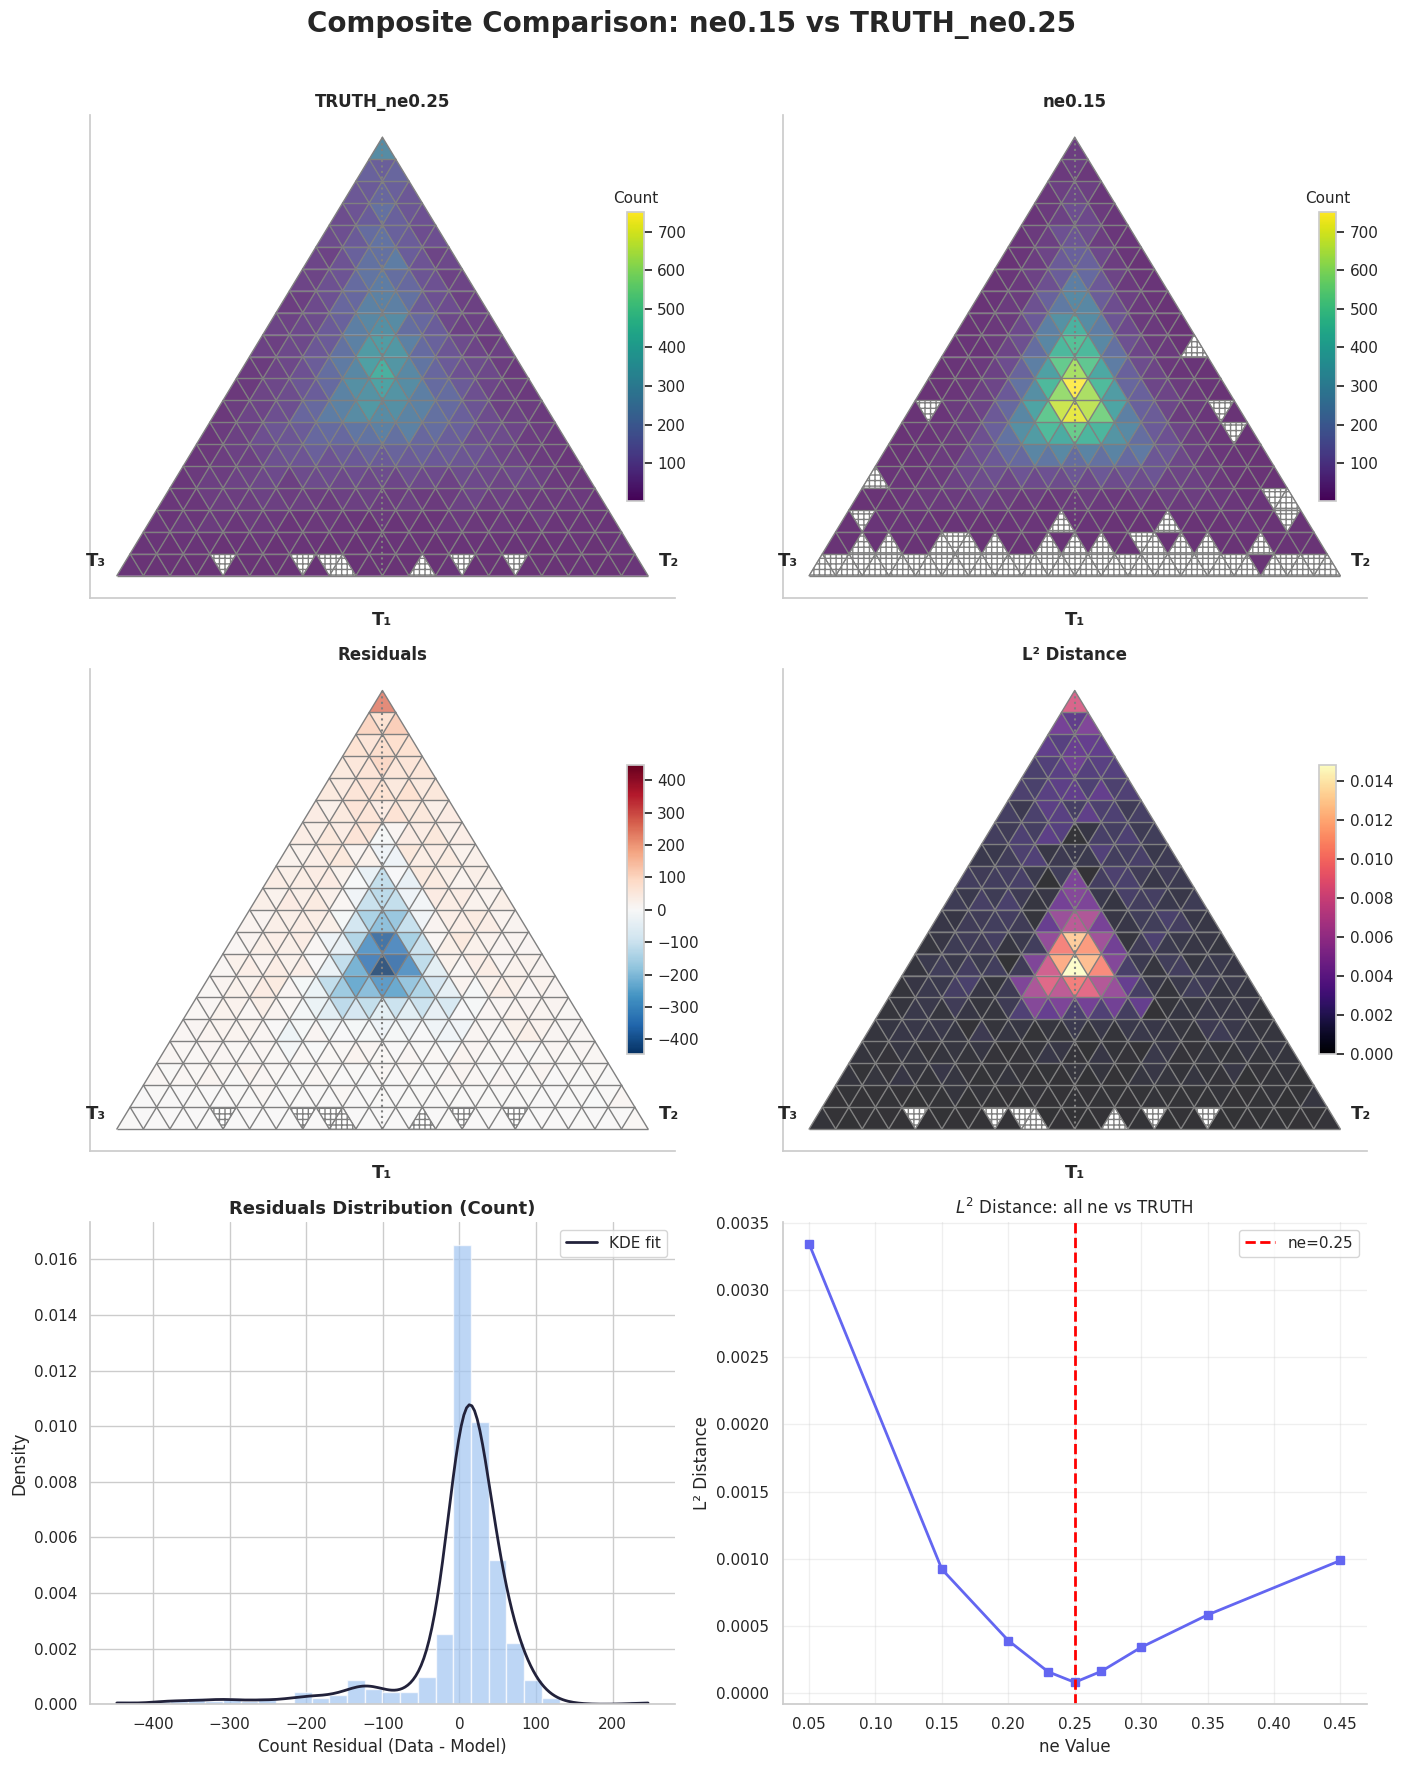

In [37]:
alpha = 0.05
#data1= dump_data("/home/hlifchit/projects/twissting_baby/Examples/data_files/ne0.25.csv")
#data2= dump_data("/home/hlifchit/projects/twissting_baby/Examples/data_files/ne0.15.csv")
results_df, statistics =  perform_enhanced_grid_analysis(data1, data2, alpha)  
all_ne_results = results_df_n

if 'l2' not in results_df.columns:
    results_df['l2'] = np.sqrt(results_df['residual_squared'])

#results_df

a=plot_composite_comparison(
    results_df, statistics, alpha,
    all_ne_results,  # DataFrame with columns ['ne_value', 'L_2'] for all ne*.csv vs TRUTH
    #ternary_results_df, # DataFrame from perform_enhanced_grid_analysis(data1, data2, alpha)
    ne_label="ne0.15", truth_label="TRUTH_ne0.25"
)

In [38]:
a.savefig("comparison_fig5.pdf", format="pdf", bbox_inches="tight")

## 4. PLOTTING REAL DATA

In [ ]:
# 📊 TWISSTNTERN ANALYSIS: LITTORINA DATASET
# ============================================================================
# 
# This cell performs comprehensive twisstntern analysis on the Littorina dataset
# and presents results in a publication-ready format for reviewers.
# 
# Analysis includes:
# - Data loading and preprocessing
# - Fundamental asymmetry analysis
# - Grid-based triangle analysis
# - Statistical summaries
# ============================================================================

print("🔬 TWISSTNTERN ANALYSIS: LITTORINA DATASET")
print("=" * 60)
print()

# Configuration
LITTORINA_FILE = Path("data_files/Littorina_data.csv").resolve()
GRANULARITY = 0.1  # Grid resolution for analysis
SAMPLE_SIZE = None  # Use all data points

# Load and process Littorina data
print("📂 Loading Littorina dataset...")
try:
    littorina_data = dump_data(LITTORINA_FILE)
    print(f"✅ Successfully loaded {len(littorina_data):,} data points")
    print(f"   File: {LITTORINA_FILE}")
    print()
except Exception as e:
    print(f"❌ Error loading data: {e}")
    raise

# Basic data summary
print("📊 DATA SUMMARY")
print("-" * 30)
print(f"Total data points: {len(littorina_data):,}")
print()



# Fundamental asymmetry analysis
print("🔄 FUNDAMENTAL ASYMMETRY ANALYSIS")
print("-" * 30)
try:
    from twisstntern.analysis import fundamental_asymmetry,triangles_analysis
    
    asym_results = fundamental_asymmetry(littorina_data)
    n_right, n_left, d_lr, g_stat, p_value = asym_results
    
    print(f"Points in right subtriangle (x > 0): {n_right:,}")
    print(f"Points in left subtriangle (x < 0):  {n_left:,}")
    print(f"Directional asymmetry (D_LR):        {d_lr:.6f}")
    print(f"G-statistic:                        {g_stat:.6f}")
    print(f"P-value:                            {p_value:.6e}")
    
    # Interpret significance
    if p_value < 0.001:
        significance = "*** (p < 0.001)"
    elif p_value < 0.01:
        significance = "** (p < 0.01)"
    elif p_value < 0.05:
        significance = "* (p < 0.05)"
    else:
        significance = "ns (p ≥ 0.05)"
    
    print(f"Significance:                       {significance}")
    print()
    
except Exception as e:
    print(f"❌ Error in asymmetry analysis: {e}")
    print()


print("✅ TWISSTNTERN ANALYSIS COMPLETE")
print("=" * 60)

🔬 TWISSTNTERN ANALYSIS: LITTORINA DATASET

📂 Loading Littorina dataset...

Attempting to read file: /home/hlifchit/projects/twissting_baby/Examples/data_files/Littorina_data.csv

Trying delimiter: ','
  Skip 0 rows: Found 3 numeric columns
  Found 3 numeric columns with delimiter ',' skipping 0 rows

Using delimiter: ',', skipping 0 rows
Successfully read entire file

Data loaded and normalized. Points with T2 == T3 removed. Remaining rows: 161516
✅ Successfully loaded 161,516 data points
   File: /home/hlifchit/projects/twissting_baby/Examples/data_files/Littorina_data.csv

📊 DATA SUMMARY
------------------------------
Total data points: 161,516

🔄 FUNDAMENTAL ASYMMETRY ANALYSIS
------------------------------
Points in right subtriangle (x > 0): 77,368
Points in left subtriangle (x < 0):  84,148
Directional asymmetry (D_LR):        -0.041977
G-statistic:                        nan
P-value:                            0.000000e+00
Significance:                       *** (p < 0.001)

✅ T

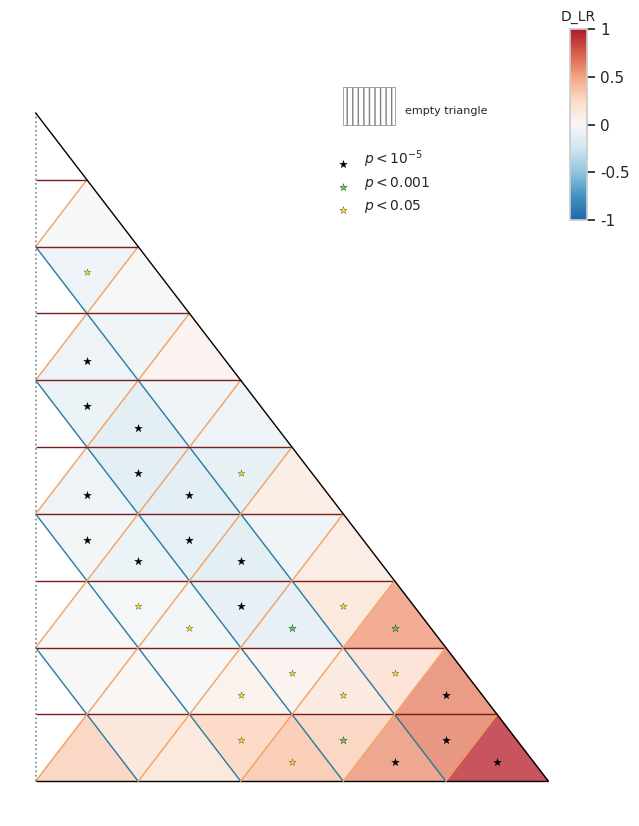

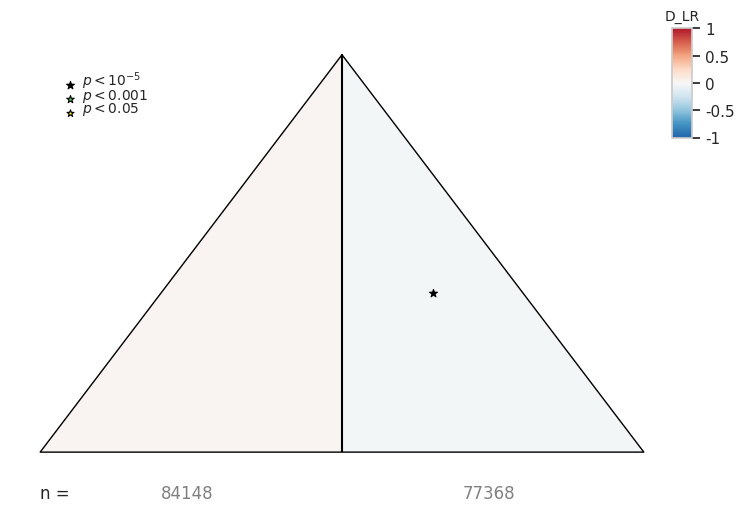

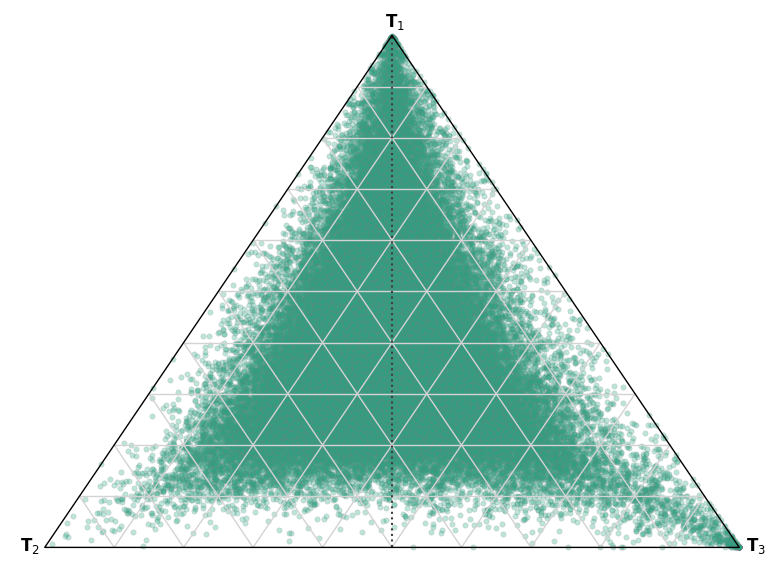

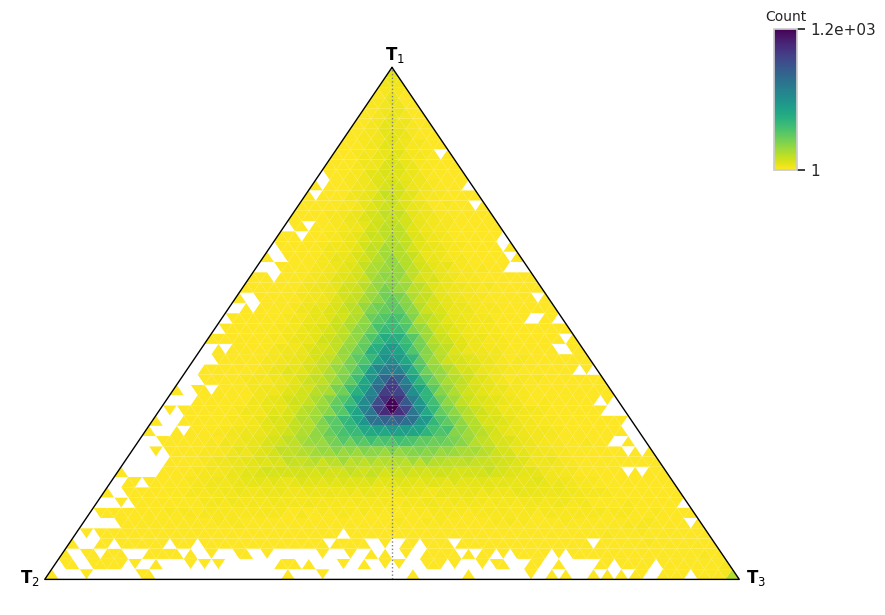

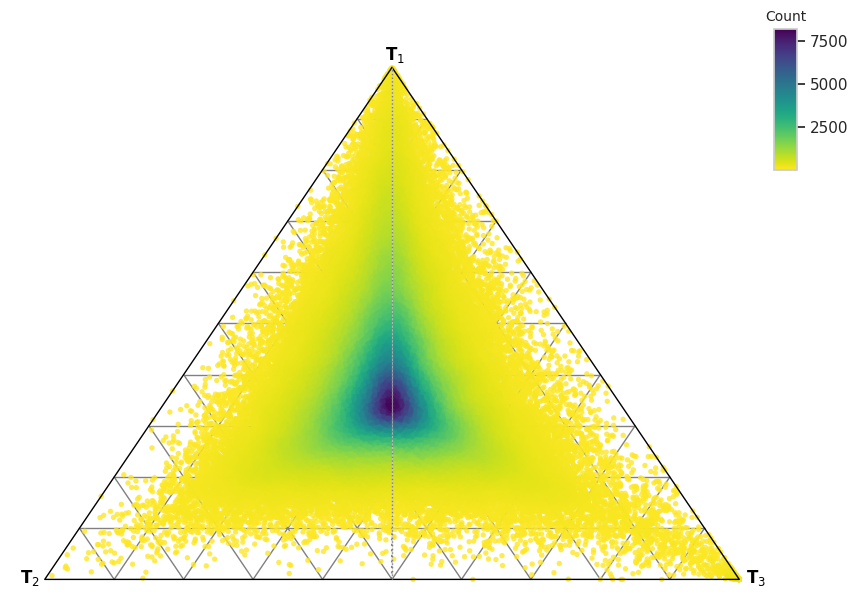

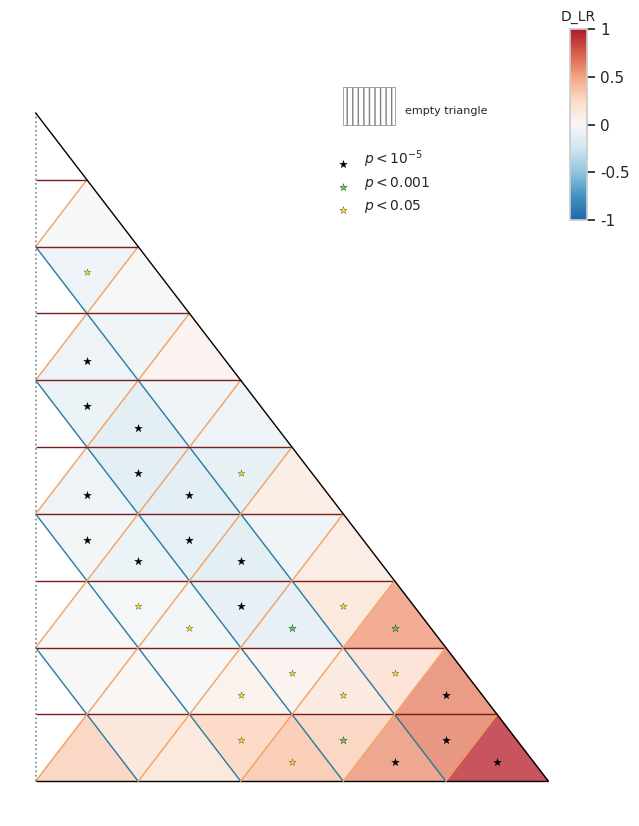

In [ ]:

# Run triangle analysis 
results = triangles_analysis(littorina_data, GRANULARITY)

# 1. Fundamental asymmetry
plot_fundamental_asymmetry(littorina_data, file_name="Littorina_fundamental_asymmetry")

# 2. Ternary plot with data points
plot(littorina_data, GRANULARITY, file_name="Littorina_ternary_plot")

# 3. Ternary heatmap (count per triangle)
plot_ternary_heatmap_data(littorina_data, 0.02, file_name="Littorina_heatmap")

# 4. Density-colored ternary plot
plot_density_colored_radcount(littorina_data, file_name="Littorina_density_colored")

# 5. D-LR triangle analysis plot
plot_results(results, GRANULARITY, file_name="Littorina_DLR_analysis")

In [ ]:
results

,"coord. (T1, T2, T3)",n_right,n_left,D-LR,g-test,p-value(g-test),index
0,"[(0.0, 0.1), (0.0, 0.1), (0.9, 1.0)]",321,13,0.922156,NaN,0.000000e+00,45
1,"[(0.0, 0.1), (0.0, 0.1), (0.8, 0.9)]",166,37,0.635468,NaN,0.000000e+00,44
2,"[(0.0, 0.1), (0.1, 0.2), (0.8, 0.9)]",70,20,0.555556,29.419377,5.829189e-08,43
3,"[(0.0, 0.1), (0.1, 0.2), (0.7, 0.8)]",95,50,0.310345,14.198807,1.644748e-04,42
4,"[(0.0, 0.1), (0.2, 0.3), (0.7, 0.8)]",23,11,0.352941,4.327923,3.749198e-02,41
5,"[(0.0, 0.1), (0.2, 0.3), (0.6, 0.7)]",77,43,0.283333,9.766550,1.777156e-03,40
6,"[(0.0, 0.1), (0.3, 0.4), (0.6, 0.7)]",24,17,0.170732,1.200997,2.731225e-01,39
7,"[(0.0, 0.1), (0.3, 0.4), (0.5, 0.6)]",54,38,0.173913,2.796808,9.445216e-02,38
8,"[(0.0, 0.1), (0.4, 0.5), (0.5, 0.6)]",17,9,0.307692,2.501930,1.137069e-01,37
9,"[(0.1, 0.2), (0.0, 0.1), (0.8, 0.9)]",105,25,0.615385,52.934775,3.448353e-13,36


### Higer simplex projecting to the 2D plane

In [ ]:
def plot_ternary_projection(
    data, t1_idx, t_focal_idx, expectation=None, colormap=None, file_name=None
):
    """
    Plot a ternary projection of high-dimensional topology weight data, with local density coloring and expectation-based scaling.

    This function visualizes data points in a ternary plot, where each point represents the relative weight of three components:
    - T1: the topology considered to represent the main or expected history
    - T_focal (T2): a selected focal topology of interest
    - T3: the sum of all remaining topologies (i.e., 1 − T1 − T_focal)

    The data may originally lie in a higher-dimensional simplex (e.g. 15 topologies), but is projected onto 3 coordinates as described above.

    Key Features:
    - Points are colored by local density in ternary space.
    - If an `expectation` value is provided for T_focal (T2), the triangle is warped to emphasize this expectation:
    - The T2 axis is rescaled non-uniformly so that its median lies at the given expectation value.
    - This transforms the geometry to reflect expected asymmetries more clearly.
    - A median line is drawn at the expected value of T_focal, if provided.
    - A legend or annotation marks the meaning of T1, T2 (focal), and T3.

    Parameters:
    - data: np.ndarray or pd.DataFrame of shape (n_samples, n_topologies). Can be full-dimensional or preprojected.
    - file_name: str, base name for the output file.
    - t1_idx: int, index of T1 in the original data.
    - t_focal_idx: int, index of T2 (focal) in the original data.
    - expectation: float or None. If given, warps the T2 axis so that the expected value appears at the triangle median.
    - colormap: str or matplotlib colormap, used for coloring by density (default: 'viridis_r').
    """


    # Handle default expectation
    show_expectation_legend = True
    if expectation is None:
        expectation = 0.5
        show_expectation_legend = False
    # Always extract T1, T2, T3 from the input, regardless of format
    if isinstance(data, pd.DataFrame) and set(['T1', 'T2', 'T3']).issubset(data.columns):
        arr = data[['T1', 'T2', 'T3']].values
        T1 = arr[:, t1_idx]
        T2 = arr[:, t_focal_idx]
    else:
        if isinstance(data, pd.DataFrame):
            arr = data.values
        else:
            arr = data
        T1 = arr[:, t1_idx]
        T2 = arr[:, t_focal_idx]
    # Piecewise transform for T2 axis
    T2_new = np.zeros_like(T2)
    for i, val in enumerate(T2):
        if val <= expectation:
            T2_new[i] = 0.5 * val / expectation if expectation > 0 else 0.0
        else:
            T2_new[i] = 0.5 + 0.5 * (val - expectation) / (1 - expectation) if expectation < 1 else 1.0
    T3 = 1 - T1 - T2_new
    ternary_df = pd.DataFrame({'T1': T1, 'T2': T2_new, 'T3': T3})
    ternary_df = ternary_df.div(ternary_df.sum(axis=1), axis=0)

    if file_name is None:
        import inspect
        callers_locals = inspect.currentframe().f_back.f_locals
        for var_name, val in callers_locals.items():
            if val is data:
                file_name = var_name
                break
        else:
            file_name = "unnamed"

    if colormap is None:
        colormap = "viridis_r"

    alpha = 0.1
    grid = True
    point_alpha = 0.8
    density_method = "neighbors"
    bandwidth = 0.02

    
    fig = plt.figure(figsize=(8, 6))
    ax = plt.axes()

    if grid:
        draw_grey_grid_lines(ax, alpha=0.1)

    x_data, y_data = cartizian(ternary_df["T1"], ternary_df["T2"], ternary_df["T3"])

    if density_method == "neighbors":
        points = np.column_stack([x_data, y_data])
        nn = NearestNeighbors(radius=bandwidth)
        nn.fit(points)
        density = nn.radius_neighbors(points, return_distance=False)
        density = np.array([len(neighbors) for neighbors in density])

    scatter = plt.scatter(
        x_data,
        y_data,
        c=density,
        cmap=colormap,
        alpha=point_alpha,
        s=15,
        edgecolors="none",
        zorder=2,
    )

    triangle_x = [0, -0.5, 0.5, 0]
    triangle_y = [h, 0, 0, h]
    ax.plot(triangle_x, triangle_y, color="k", linewidth=1, zorder=3)

    ax.vlines(x=0, ymin=0, ymax=h, colors="darkblue", linestyles="--", linewidth=0.8, zorder=5)

    label_color = "black"
    label_size = 12
    ax.text(-0.01, 0.88, r"$\mathbf{T}_1$", size=label_size, color=label_color)
    ax.text(0.51, -0.005, r"$\mathbf{T}_3$", size=label_size, color=label_color)
    ax.text(-0.535, -0.005, r"$\mathbf{T}_2$", size=label_size, color=label_color)

    for spine in ax.spines.values():
        spine.set_color("none")
    ax.set_yticks([])
    ax.set_xticks([])

    sm = plt.cm.ScalarMappable(
        cmap=colormap,
        norm=plt.cm.colors.Normalize(vmin=density.min(), vmax=density.max()),
    )
    sm.set_array([])
    cax = inset_axes(
        ax,
        width="3%",
        height="25%",
        loc="upper right",
        bbox_to_anchor=(0.05, 0.05, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=1,
    )
    cbar = plt.colorbar(sm, cax=cax)
    cbar.ax.set_title("Count", fontsize=10, pad=6)

    legend_text = r"$T_1$ = [{}], $T_2$ = [{}], $T_3$ = all others".format(t1_idx, t_focal_idx)
    fig.text(0.02, 0.98, legend_text, ha='left', va='top', fontsize=12, color='black')

    if show_expectation_legend:
        fig.text(0.5, 0.12, rf"Expectation: $T_2$ = {expectation:.4f}", color='darkblue', fontsize=13, ha='center', va='top')

    title = f"{file_name}_expectation_{expectation:.4f}.png"
    fig.savefig(title, dpi=150, bbox_inches='tight')
    return fig

# producing some fake data in 1 the14 dimension simplex (15 positive coordinates that sum to 1)

def generate_simplex_data(n_samples, n_dimensions, alpha_value=1.0):
    """
    Generate a dataset of Dirichlet-distributed points on a simplex.
    Args:
        n_samples: number of samples (rows)
        n_dimensions: number of dimensions (columns)
        alpha_value: Dirichlet concentration parameter (default 1.0 for uniform)
    Returns:
        np.ndarray of shape (n_samples, n_dimensions)
    """
    alpha = np.ones(n_dimensions) * alpha_value
    return np.random.dirichlet(alpha, size=n_samples)



Note to self (just for general knowledge):

explaining the alpha_value
The Dirichlet distribution PDF for K-dimensional vector x = (x₁, ..., x_K), where each xᵢ > 0 and ∑xᵢ = 1, is:

    f(x₁, ..., x_K; α₁, ..., α_K) = (1 / B(α)) * ∏_{i=1}^K xᵢ^{αᵢ - 1}

where:
    α = (α₁, ..., α_K) are the concentration parameters (αᵢ > 0),
    B(α) is the multivariate Beta function:

    B(α) = ∏_{i=1}^K Γ(αᵢ) / Γ(∑_{i=1}^K αᵢ)

and Γ is the Gamma function (generalization of factorial).
Dirichlet alpha value explanation:

When using alpha = np.ones(K) * alpha_value, the distribution is symmetric,
but the *shape* of the distribution depends on the value of alpha_value:

  - alpha_value = 1:   Uniform distribution over the simplex (all points equally likely)
  - alpha_value < 1:   Points cluster near the corners (sparse vectors, one value ≈ 1)
  - alpha_value > 1:   Points cluster near the center (balanced vectors, all values ≈ 1/K)

This allows you to control how "peaked" or "flat" the distribution is across the simplex.

Note: Regardless of alpha, the sampled vectors always have positive entries that sum to 1.

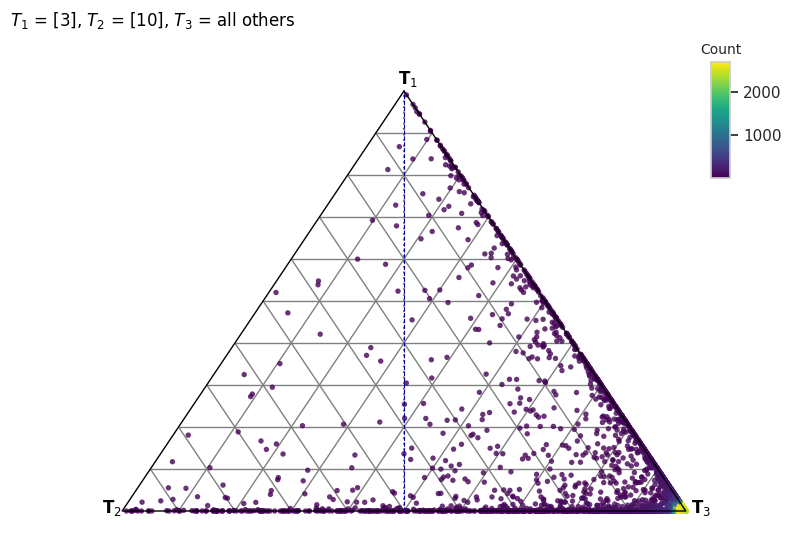

In [ ]:
# Number of samples and dimensions
n_samples = 5000
n_dimensions = 15

# Generate fake data
fake_data = generate_simplex_data(n_samples, n_dimensions, 0.1)

a=plot_ternary_projection(
    fake_data, 3, 10,colormap="viridis")

In [ ]:
#### DOESNT YET WORK-- NOT REALLY NEEDED THOUGH

def plot_ternary_projection_stretched(data, t_focal, file_name, alpha=0.1):
    """
    Plot a ternary diagram with expectation-based axis stretching and custom grid lines.
    - data: dict with keys 'T1', 'T2', 'T3' (arrays/lists of values in [0,1])
    - t_focal: expectation value for T2 (float in [0,1])
    - file_name: output file name (string)
    - alpha: grid granularity (default 0.1)
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from twisstntern.utils import cartizian, T1, T2, T3, T1_lim, T2_lim, T3_lim, h

    fig = plt.figure(figsize=(8, 6))
    ax = plt.axes()

    # Draw triangle by connecting vertices A (top), B (left), and C (right)
    triangle_x = [0, -0.5, 0.5, 0]  # A → B → C → A
    triangle_y = [h, 0, 0, h]
    ax.plot(triangle_x, triangle_y, color="k", linewidth=1, zorder=3)
    ax.set_xticks([])
    ax.set_yticks([])

    # --- Helper: Stretch mapping for T2 and T1 ---
    def stretch_axis(val, expectation):
        if val <= expectation:
            return (val / expectation) * t_focal if expectation > 0 else 0
        else:
            return t_focal + ((val - expectation) / (1 - expectation)) * (1 - t_focal) if expectation < 1 else 1

    # --- T2 grid lines ---
    # Partition [0, expectation] into 4 equal segments
    t2_lower = np.linspace(0, t_focal, 5)
    # For values above expectation, draw at next 0.x after t_focal up to 1.0
    t2_upper_start = np.ceil(t_focal * 10) / 10
    t2_upper = np.arange(t2_upper_start, 1.01, alpha)
    t2_grid = np.concatenate([t2_lower, t2_upper])
    t2_grid = np.unique(np.round(t2_grid, 6))

    # --- T1 grid lines ---
    t1_expect = 1 - t_focal
    t1_lower = np.linspace(0, t1_expect, 5)
    t1_upper_start = np.ceil(t1_expect * 10) / 10
    t1_upper = np.arange(t1_upper_start, 1.01, alpha)
    t1_grid = np.concatenate([t1_lower, t1_upper])
    t1_grid = np.unique(np.round(t1_grid, 6))

    # --- T3 grid lines (standard) ---
    t3_grid = np.arange(0, 1.01, alpha)

    # --- Draw T2 grid lines ---
    for t2 in t2_grid:
        x2_l, x2_r = T2_lim(t2)
        x2 = np.linspace(x2_l, x2_r, 100)
        ax.plot(x2, T2(t2, x2), color="dodgerblue" if t2 <= t_focal else "#277DA1", linewidth=1, alpha=0.8 if t2 <= t_focal else 0.6)
        # Tick label
        if t2 == t_focal:
            ax.plot(x2, T2(t2, x2), color="red", linewidth=2, alpha=1.0, zorder=4)
        # Place tick at left edge
        x_tick = x2_l
        y_tick = T2(t2, x_tick)
        ax.text(x_tick-0.04, y_tick, f"{t2:.2f}", size=7, color="red" if t2 == t_focal else ("dodgerblue" if t2 <= t_focal else "#277DA1"))

    # --- Draw T1 grid lines ---
    for t1 in t1_grid:
        x1_l, x1_r = T1_lim(t1)
        ax.hlines(y=t1 * h, xmin=x1_l, xmax=x1_r, color="crimson" if t1 <= t1_expect else "#7B1E1E", linewidth=1, alpha=0.8 if t1 <= t1_expect else 0.6)
        # Tick label
        if np.isclose(t1, t1_expect):
            ax.hlines(y=t1 * h, xmin=x1_l, xmax=x1_r, color="red", linewidth=2, alpha=1.0, zorder=4)
        ax.text(x1_r+0.01, t1*h, f"{t1:.2f}", size=7, color="red" if np.isclose(t1, t1_expect) else ("crimson" if t1 <= t1_expect else "#7B1E1E"))

    # --- Draw T3 grid lines (standard) ---
    for t3 in t3_grid:
        x3_l, x3_r = T3_lim(t3)
        x3 = np.linspace(x3_l, x3_r, 100)
        ax.plot(x3, T3(t3, x3), color="gold", linewidth=1, alpha=0.7)
        # Tick label at base
        ax.text(x3_r, -0.03, f"{t3:.2f}", size=7, color="darkgoldenrod")

    # --- Central vertical line ---
    ax.vlines(x=0, ymin=0, ymax=h, colors="grey", linestyles=":")

    # --- Data points: map to stretched axes ---
    def stretch_point(t1, t2, t3):
        # Map T2 and T1 using the stretching logic, T3 is 1-T1-T2
        t2s = stretch_axis(t2, t_focal)
        t1s = stretch_axis(t1, 1-t_focal)
        t3s = 1 - t1s - t2s
        return t1s, t2s, t3s

    t1s, t2s, t3s = [], [], []
    for t1, t2, t3 in zip(data["T1"], data["T2"], data["T3"]):
        s1, s2, s3 = stretch_point(t1, t2, t3)
        t1s.append(s1)
        t2s.append(s2)
        t3s.append(s3)
    x_data, y_data = cartizian(np.array(t1s), np.array(t2s), np.array(t3s))
    ax.scatter(x_data, y_data, color = "lightsteelblue", alpha=0.5, s=9)

    # --- Corner labels ---
    ax.text(-0.01, 0.88, 'T1', size=12, color="crimson")
    ax.text(0.51, -0.005, 'T3', size=12, color= "darkgoldenrod")
    ax.text(-0.535, -0.005, 'T2', size=12, color = "dodgerblue")

    # --- Remove box lines ---
    for spine in ax.spines.values():
        spine.set_visible(False)

    # --- Save plot ---
    title = file_name + f"_stretched_granuality_{alpha}.png"
    plt.savefig(title)
    return fig


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

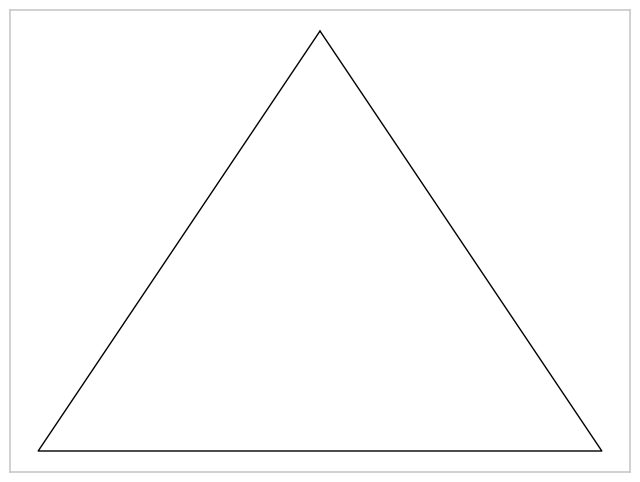

In [ ]:
plot_ternary_projection_stretched(fake_data, [0],"df", alpha=0.1)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Import necessary geometric functions from your project's utils
from twisstntern.utils import cartizian, T1, T2, T3, T1_lim, T2_lim, T3_lim, h

def plot_ternary_projection_with_adaptive_grid(
    data, t1_idx, t_focal_idx, expectation=None, colormap=None, file_name=None
):
    """
    Plot a ternary projection with density coloring and an adaptive grid that
    reflects the non-linear stretching of the T2 axis.

    The T2 axis is warped around the 'expectation' value, and the grid lines
    are drawn with higher density around this value to make the transformation clear.

    Parameters:
    - data: np.ndarray or pd.DataFrame of shape (n_samples, n_topologies).
    - file_name: str, base name for the output file.
    - t1_idx: int, index of T1 in the original data.
    - t_focal_idx: int, index of T2 (focal) in the original data.
    - expectation: float or None. The value around which to warp the T2 axis.
    - colormap: str or matplotlib colormap for density coloring.
    """
    # --- 1. Data and Parameter Setup ---
    if expectation is None:
        expectation = 0.5
        show_expectation_legend = False
    else:
        show_expectation_legend = True

    if isinstance(data, pd.DataFrame):
        arr = data.values
    else:
        arr = data

    T1 = arr[:, t1_idx]
    T2 = arr[:, t_focal_idx]

    # --- 2. Stretched Coordinate Calculation for Data Points ---
    T2_new = np.zeros_like(T2)
    mask_le = T2 <= expectation
    if expectation > 0:
        T2_new[mask_le] = 0.5 * T2[mask_le] / expectation
    mask_gt = T2 > expectation
    if expectation < 1:
        T2_new[mask_gt] = 0.5 + 0.5 * (T2[mask_gt] - expectation) / (1 - expectation)
    else:
        T2_new[mask_gt] = 1.0

    T3_new = 1 - T1 - T2_new
    ternary_df = pd.DataFrame({'T1': T1, 'T2': T2_new, 'T3': T3_new})

    # --- 3. Plotting Initialization ---
    if file_name is None: file_name = "ternary_projection"
    if colormap is None: colormap = "viridis_r"

    fig = plt.figure(figsize=(8, 6))
    ax = plt.axes()

    # --- 4. Adaptive Grid Line Drawing (from your logic) ---
    alpha = 0.1 # Grid granularity
    
    # T2 grid lines are dense around the expectation value
    t2_lower = np.linspace(0, expectation, 5)
    t2_upper_start = np.ceil(expectation * 10) / 10
    t2_upper = np.arange(t2_upper_start, 1.01, alpha)
    t2_grid = np.unique(np.concatenate([t2_lower, t2_upper]))

    # T1 grid lines are dense around its corresponding expectation (1 - expectation)
    t1_expect = 1 - expectation
    t1_lower = np.linspace(0, t1_expect, 5)
    t1_upper_start = np.ceil(t1_expect * 10) / 10
    t1_upper = np.arange(t1_upper_start, 1.01, alpha)
    t1_grid = np.unique(np.concatenate([t1_lower, t1_upper]))
    
    # Draw T2 grid lines
    for t2_val in t2_grid:
        x2_l, x2_r = T2_lim(t2_val)
        x2_coords = np.linspace(x2_l, x2_r, 100)
        is_focal_line = np.isclose(t2_val, expectation)
        ax.plot(x2_coords, T2(t2_val, x2_coords),
                color="red" if is_focal_line else "dodgerblue",
                linewidth=2 if is_focal_line else 1,
                alpha=1.0 if is_focal_line else 0.7,
                zorder=4 if is_focal_line else 1)

    # Draw T1 grid lines
    for t1_val in t1_grid:
        x1_l, x1_r = T1_lim(t1_val)
        is_focal_line = np.isclose(t1_val, t1_expect)
        ax.hlines(y=t1_val * h, xmin=x1_l, xmax=x1_r,
                  color="red" if is_focal_line else "crimson",
                  linewidth=2 if is_focal_line else 1,
                  alpha=1.0 if is_focal_line else 0.7,
                  zorder=4 if is_focal_line else 1)

    # Draw standard T3 grid lines
    for t3_val in np.arange(0, 1.01, alpha):
        x3_l, x3_r = T3_lim(t3_val)
        x3_coords = np.linspace(x3_l, x3_r, 100)
        ax.plot(x3_coords, T3(t3_val, x3_coords), color="gold", linewidth=1, alpha=0.6)

    # --- 5. Density Calculation & Scatter Plot (of stretched data) ---
    x_data, y_data = cartizian(ternary_df["T1"], ternary_df["T2"], ternary_df["T3"])
    points = np.column_stack([x_data, y_data])
    nn = NearestNeighbors(radius=0.02).fit(points)
    density = np.array([len(neighbors) for neighbors in nn.radius_neighbors(points, return_distance=False)])

    plt.scatter(x_data, y_data, c=density, cmap=colormap, alpha=0.8, s=15, edgecolors="none", zorder=2)

    # --- 6. Final Touches (Triangle, Labels, Colorbar) ---
    triangle_x, triangle_y = [0, -0.5, 0.5, 0], [h, 0, 0, h]
    ax.plot(triangle_x, triangle_y, color="k", linewidth=1.5, zorder=3)
    ax.vlines(x=0, ymin=0, ymax=h, colors="darkblue", linestyles="--", linewidth=0.8, zorder=5)

    ax.text(-0.01, 0.88, r"$\mathbf{T}_1$", size=12, color="crimson", weight='bold')
    ax.text(0.51, -0.005, r"$\mathbf{T}_3$", size=12, color="darkgoldenrod", weight='bold')
    ax.text(-0.535, -0.005, r"$\mathbf{T}_2$", size=12, color="dodgerblue", weight='bold')

    for spine in ax.spines.values(): spine.set_color("none")
    ax.set_yticks([]); ax.set_xticks([])

    sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=density.min(), vmax=density.max()))
    cax = inset_axes(
        ax, width="3%", height="25%", loc="upper right",
        bbox_to_anchor=(0.05, 0.05, 1, 1), bbox_transform=ax.transAxes, borderpad=1
    )
    cbar = plt.colorbar(sm, cax=cax)
    cbar.ax.set_title("Count", fontsize=10, pad=6)

    legend_text = f"$T_1$ = [{t1_idx}], $T_2$ = [{t_focal_idx}], $T_3$ = all others"
    fig.text(0.02, 0.98, legend_text, ha='left', va='top', fontsize=12)
    if show_expectation_legend:
        fig.text(0.5, 0.12, f"Expectation: $T_2$ = {expectation:.4f}", color='darkblue', fontsize=13, ha='center', va='top')

    title = f"{file_name}_stretched_adaptive_grid_exp_{expectation:.4f}.png"
    fig.savefig(title, dpi=150, bbox_inches='tight')
    return fig

TypeError: 'numpy.ndarray' object is not callable

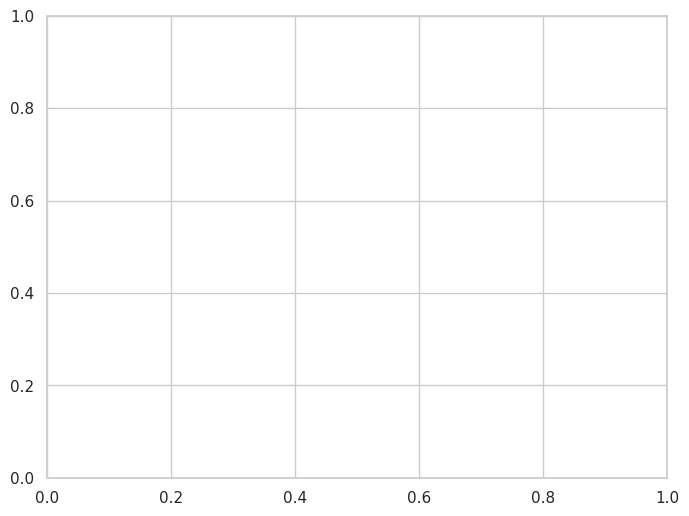

In [ ]:
b=plot_ternary_projection_with_adaptive_grid(
    fake_data, 3, 10,colormap="viridis")